# Binary-resolution experiment: seed 00, epsilon_ff = 0.03

CMD-only analysis of binary angular resolution.  The H-R diagram is
deliberately excluded because it is an intrinsic physical diagram rather
than a wavelength-dependent imaging observable.

Experiments:
- all current binaries resolved;
- all current binaries unresolved;
- line-of-sight resolution for XY, XZ, and YZ sky-plane projections.

Current multiplicity is recomputed at every snapshot with
snapshot.resolve_set(snapshot.unresolved_stars, split_set=True), so binary
formation, disruption, exchanges, and orbital motion are all allowed.

For each CMD, the angular-resolution criterion uses the LONGEST-wavelength
filter in that CMD and the correct telescope primary-mirror diameter:
- JWST F070W-F200W and F182M-F200W: F200W, D = 6.5 m;
- HST  F555W-F814W: F814W, D = 2.4 m.

Rayleigh criterion:
    theta_R = 1.22 * lambda / D

At the adopted cluster distance of 410 pc, a binary is unresolved in a
given projection when its instantaneous projected separation is <= the
physical separation corresponding to theta_R.

Unresolved binaries are combined in FLUX independently in every filter
before CMD colors are calculated.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import math
import os
import shutil
import sys
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table
from matplotlib.lines import Line2D

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/'
)
SIMULATION_PATH = Path(
    '/standard/Tan_JC/backup_protoclusters/multiples/M3000new/'
    'sigma0p1/fiducial/sfe_ff003/00'
)

# CMD-only binary-resolution products.
OUTPUT_DIR = Path.cwd() / 'binary_resolution_seed00_cmd_outputs'
CACHE_DIR = Path.cwd() / 'binary_resolution_seed00_cmd_cache'
ISO_CACHE_DIR = Path.cwd() / 'iso_cache'

RESET_ISO_CACHE = False
RECOMPUTE_BASE_CATALOGS = False
RECOMPUTE_METRICS = False
SAVE_FIGURES = True
SHOW_FIGURES = True

CLUSTER_MASS_MSUN = 3000
SIGMA_CLOUD = 0.1
EPSILON_FF = 0.03
SEED = '00'

USE_ROTATING_MERGED = False
AKS = 0.0

# Use one consistent cluster distance for both SPISEA photometry and the
# conversion of angular resolution into projected physical separation.
DISTANCE_PC = 410.0
OBSERVING_DISTANCE_PC = DISTANCE_PC

RAYLEIGH_FACTOR = 1.22
METALLICITY = 0.0
ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)
ANALYSIS_TIMES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
DISPLAY_TIMES_MYR = np.array([1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0, 20.0])

TEFF_MIN_K = 3000.0
TEFF_MAX_K = 3600.0
N_BINS = 6
REFERENCE_BIN_AGE_MYR = 1.0
MIN_STARS_PER_BIN = 8
CLIP_YOUNG_TO_GRID = True
L_SUN_WATTS = 3.846e26
PC_TO_AU = 206264.80624709636
RAD_TO_ARCSEC = 206264.80624709636

FILTER_OBSMODES = {
    'F070W': 'jwst,F070W',
    'F182M': 'jwst,F182M',
    'F200W': 'jwst,F200W',
    'F555W': 'wfc3,uvis1,f555w',
    'F814W': 'wfc3,uvis1,f814w',
}
ALL_FILTERS = list(FILTER_OBSMODES.values())

# Resolution information for the longest-wavelength band used by each CMD.
# The nominal central wavelength is adequate for this diffraction-limit
# experiment; the important correction is using each telescope's own aperture.
FILTER_RESOLUTION_CONFIG = {
    'F200W': {
        'telescope': 'JWST',
        'wavelength_um': 2.00,
        'diameter_m': 6.5,
    },
    'F814W': {
        'telescope': 'HST',
        'wavelength_um': 0.814,
        'diameter_m': 2.4,
    },
}

PROJECTIONS = {
    'XY': ('x', 'y'),
    'XZ': ('x', 'z'),
    'YZ': ('y', 'z'),
}

ALL_RESOLVED = 'all_resolved'
ALL_UNRESOLVED = 'all_unresolved'
LOS_MODES = [f'los_{p.lower()}' for p in PROJECTIONS]
ALL_MODES = [ALL_RESOLVED, ALL_UNRESOLVED, *LOS_MODES]
MODE_LABELS = {
    ALL_RESOLVED: 'All binaries resolved',
    ALL_UNRESOLVED: 'All binaries unresolved',
    'los_xy': 'LOS: XY sky plane',
    'los_xz': 'LOS: XZ sky plane',
    'los_yz': 'LOS: YZ sky plane',
}

## CMD definitions

In [3]:
@dataclass(frozen=True)
class Diagram:
    key: str
    title: str
    xlabel: str
    ylabel: str
    blue: str
    red: str
    y_filter: str
    invert_y: bool
    resolution_filter: str


DIAGRAMS = [
    Diagram(
        'f070w_f200w', 'JWST F070W - F200W vs. F200W',
        'F070W - F200W', 'F200W',
        'F070W', 'F200W', 'F200W', True,
        resolution_filter='F200W',
    ),
    Diagram(
        'f182m_f200w', 'JWST F182M - F200W vs. F200W',
        'F182M - F200W', 'F200W',
        'F182M', 'F200W', 'F200W', True,
        resolution_filter='F200W',
    ),
    Diagram(
        'hst_f555w_f814w', 'HST F555W - F814W vs. F814W',
        'F555W - F814W', 'F814W',
        'F555W', 'F814W', 'F814W', True,
        resolution_filter='F814W',
    ),
]

## General helpers

In [4]:
def show_table(df, n=None):
    df2 = df.head(n) if n is not None else df
    try:
        from IPython.display import display
        display(df2)
    except Exception:
        print(df2.to_string(index=False))


def normalize_name(value):
    return ''.join(ch.lower() for ch in str(value) if ch.isalnum())


def prepare_dirs():
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)
    for p in (OUTPUT_DIR, CACHE_DIR, ISO_CACHE_DIR):
        p.mkdir(parents=True, exist_ok=True)
    (CACHE_DIR / 'base_catalogs').mkdir(parents=True, exist_ok=True)


def finish_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches='tight')
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


prepare_dirs()
if not SIMULATION_PATH.is_dir():
    raise FileNotFoundError(SIMULATION_PATH)

## Merged evolutionary model / isochrones

In [5]:
class MergedBaraffePisaEkstromParsecDAT:
    def __init__(self, root_dir: Path | str, rot=False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)
        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []
        self.grid_dir = self.root_dir / ('z015_rot' if rot else 'z015_norot')
        if not self.grid_dir.is_dir():
            raise FileNotFoundError(self.grid_dir)
        self.age_file_map = {}
        for p in sorted(self.grid_dir.glob('iso_*.dat')):
            try:
                age = float(p.stem.split('_')[1])
            except (IndexError, ValueError):
                continue
            self.age_file_map[round(age, 2)] = p
        if not self.age_file_map:
            raise FileNotFoundError(f'No iso_*.dat in {self.grid_dir}')
        self.age_list = np.array(sorted(self.age_file_map), float)

    def isochrone(self, age=1e6, metallicity=0.0):
        requested = math.log10(age)
        if requested < self.age_list[0] or requested > self.age_list[-1]:
            raise ValueError(f'logAge {requested:.4f} outside grid')
        selected = float(self.age_list[np.argmin(np.abs(self.age_list - requested))])
        path = self.age_file_map[round(selected, 2)]
        dtype = [
            ('mass', 'f8'), ('logT', 'f8'), ('logL', 'f8'), ('logg', 'f8'),
            ('logT_WR', 'f8'), ('mass_current', 'f8'), ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]
        data = np.genfromtxt(path, comments='#', dtype=dtype, encoding='utf-8')
        iso = Table(np.atleast_1d(data))
        iso.add_column(Column(
            ~np.isclose(
                np.asarray(iso['logT'], float),
                np.asarray(iso['logT_WR'], float),
                rtol=0.0, atol=1e-8,
            ),
            name='isWR',
        ))
        iso.meta.update({
            'log_age': selected,
            'log_age_requested': requested,
            'metallicity_in': metallicity,
            'metallicity_act': 0.0,
            'source_file': str(path),
        })
        return iso


@dataclass
class IsoGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame
    filter_columns: dict[str, str]


def resolve_filter_column(colnames, filter_name):
    target = normalize_name(filter_name)
    candidates = [
        c for c in colnames
        if normalize_name(c).startswith('m') and normalize_name(c).endswith(target)
    ]
    instrument = 'hst' if filter_name in {'F555W', 'F814W'} else 'jwst'
    preferred = [c for c in candidates if instrument in normalize_name(c)]
    if len(preferred) == 1:
        return preferred[0]
    if len(candidates) == 1:
        return candidates[0]
    raise KeyError(f'Cannot resolve {filter_name}; candidates={candidates}')


def safe_interpolate(age_myr, mass, grid, log_ages, filters):
    try:
        with warnings.catch_warnings(), \
             contextlib.redirect_stdout(io.StringIO()), \
             contextlib.redirect_stderr(io.StringIO()):
            warnings.simplefilter('ignore')
            result = interpolator.interpolate(age_myr, mass, grid, log_ages, list(filters))
        if result is None:
            return None
        result = np.asarray(result, float)
        if result.size != 3 + len(filters) or not np.all(np.isfinite(result)):
            return None
        return result
    except Exception:
        return None


def build_iso_grid(evo_model):
    isos, records, filter_columns = [], [], None
    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f'Building/loading {age_myr:4.1f} Myr isochrone')
        try:
            iso = synthetic.IsochronePhot(
                log_age, AKS, DISTANCE_PC, metallicity=METALLICITY,
                evo_model=evo_model, atm_func=ATM_FUNC, red_law=RED_LAW,
                filters=ALL_FILTERS, iso_dir=str(ISO_CACHE_DIR),
            )
            current = {
                name: resolve_filter_column(iso.points.colnames, name)
                for name in FILTER_OBSMODES
            }
            if filter_columns is None:
                filter_columns = current
            elif current != filter_columns:
                raise RuntimeError('Magnitude columns changed across ages')
            mass = np.asarray(iso.points['mass'], float)
            isos.append(iso)
            records.append({
                'age_myr': age_myr, 'status': 'success', 'n_points': len(iso.points),
                'mass_min': np.nanmin(mass), 'mass_max': np.nanmax(mass), 'error': '',
            })
        except Exception as exc:
            isos.append(None)
            records.append({
                'age_myr': age_myr, 'status': 'failed', 'n_points': 0,
                'mass_min': np.nan, 'mass_max': np.nan, 'error': str(exc),
            })
            print(f'  FAILED: {exc}')
    if filter_columns is None:
        raise RuntimeError('No isochrones built')
    return IsoGrid(
        ISO_AGES_MYR.copy(), ISO_LOG_AGES.copy(), isos,
        pd.DataFrame(records), filter_columns,
    )


evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT, rot=USE_ROTATING_MERGED
)
ISO_GRID = build_iso_grid(evo_model)
ISO_GRID.coverage.to_csv(OUTPUT_DIR / 'isochrone_coverage.csv', index=False)
failed = ISO_GRID.coverage[ISO_GRID.coverage['status'] != 'success']
if len(failed):
    raise RuntimeError(f'Isochrone failures:\n{failed.to_string(index=False)}')

Building/loading  1.0 Myr isochrone


Building/loading  1.5 Myr isochrone
Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone


Building/loading  4.0 Myr isochrone


Building/loading  4.5 Myr isochrone
Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone
Building/loading  6.0 Myr isochrone
Building/loading  6.5 Myr isochrone


Building/loading  7.0 Myr isochrone
Building/loading  7.5 Myr isochrone


...

Building/loading 11.0 Myr isochrone
Building/loading 11.5 Myr isochrone
Building/loading 12.0 Myr isochrone
Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone
Building/loading 13.5 Myr isochrone
Building/loading 14.0 Myr isochrone


Building/loading 14.5 Myr isochrone


Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone
Building/loading 16.0 Myr isochrone
Building/loading 16.5 Myr isochrone
Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone


Building/loading 18.0 Myr isochrone


Building/loading 18.5 Myr isochrone
Building/loading 19.0 Myr isochrone
Building/loading 19.5 Myr isochrone
Building/loading 20.0 Myr isochrone


## Static 1 Myr CMD measurement bins

In [6]:
def nearest_iso_index(age_myr):
    age = np.clip(age_myr, ISO_GRID.ages_myr.min(), ISO_GRID.ages_myr.max())
    return int(np.argmin(np.abs(ISO_GRID.ages_myr - age)))


def isochrone_xy(iso, diagram):
    teff = np.asarray(iso.points['Teff'], float)
    blue = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.blue]], float)
    red = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.red]], float)
    y = np.asarray(iso.points[ISO_GRID.filter_columns[diagram.y_filter]], float)
    return blue - red, y, teff


def interpolate_color_at_teff(iso, diagram, target, half_width=250.0):
    color, _, teff = isochrone_xy(iso, diagram)
    good = (
        np.isfinite(color) & np.isfinite(teff)
        & (teff >= target - half_width) & (teff <= target + half_width)
    )
    t, c = teff[good], color[good]
    if len(t) < 2:
        raise RuntimeError(f'Not enough points near {target:g} K for {diagram.key}')
    order = np.argsort(t)
    t, c = t[order], c[order]
    ut, inv = np.unique(t, return_inverse=True)
    sums, counts = np.zeros_like(ut), np.zeros_like(ut)
    np.add.at(sums, inv, c)
    np.add.at(counts, inv, 1)
    uc = sums / counts
    if target < ut.min() or target > ut.max():
        raise RuntimeError(f'{target:g} K not bracketed for {diagram.key}')
    return float(np.interp(target, ut, uc))


def build_static_bins():
    idx = nearest_iso_index(REFERENCE_BIN_AGE_MYR)
    if not np.isclose(ISO_GRID.ages_myr[idx], REFERENCE_BIN_AGE_MYR):
        raise RuntimeError('1 Myr isochrone unavailable')

    iso = ISO_GRID.isochrones[idx]
    out = {}
    for d in DIAGRAMS:
        x3000 = interpolate_color_at_teff(iso, d, TEFF_MIN_K)
        x3600 = interpolate_color_at_teff(iso, d, TEFF_MAX_K)
        edges = np.linspace(
            min(x3000, x3600),
            max(x3000, x3600),
            N_BINS + 1,
        )
        out[d.key] = {
            'edges': edges,
            'x_3000': x3000,
            'x_3600': x3600,
            'bin_width': float(edges[1] - edges[0]),
        }
    return out


STATIC_BINS = build_static_bins()
rows = []
for d in DIAGRAMS:
    z = STATIC_BINS[d.key]
    for i, edge in enumerate(z['edges']):
        rows.append({
            'diagram': d.key,
            'diagram_title': d.title,
            'reference_isochrone_age_myr': REFERENCE_BIN_AGE_MYR,
            'x_at_3000k': z['x_3000'],
            'x_at_3600k': z['x_3600'],
            'edge_index': i,
            'x_edge': float(edge),
            'bin_width': z['bin_width'],
        })
pd.DataFrame(rows).to_csv(
    OUTPUT_DIR / 'static_1myr_bin_definitions.csv',
    index=False,
)


def intervals(edges):
    return [(float(edges[i]), float(edges[i + 1])) for i in range(len(edges) - 1)]


def interval_mask(values, low, high, is_last=False):
    values = np.asarray(values, float)
    return ((values >= low) & (values <= high)) if is_last else (
        (values >= low) & (values < high)
    )


def target_temperature_mask(teff):
    teff = np.asarray(teff, float)
    return np.isfinite(teff) & (teff >= TEFF_MIN_K) & (teff <= TEFF_MAX_K)

## Telescope/filter angular-resolution thresholds

The longest-wavelength filter in each CMD sets the resolution criterion.
The telescope diameter is chosen from the instrument that actually supplies
that filter.  Thus the HST CMD uses D=2.4 m, not the JWST 6.5 m aperture.

In [7]:
def rayleigh_resolution(wavelength_um, diameter_m, distance_pc):
    wavelength_m = float(wavelength_um) * 1e-6
    diameter_m = float(diameter_m)
    distance_pc = float(distance_pc)

    theta_rad = RAYLEIGH_FACTOR * wavelength_m / diameter_m
    theta_arcsec = theta_rad * RAD_TO_ARCSEC

    # By definition, 1 arcsec at 1 pc subtends 1 AU.
    physical_au = theta_arcsec * distance_pc
    physical_pc = physical_au / PC_TO_AU

    return {
        'wavelength_um': float(wavelength_um),
        'diameter_m': diameter_m,
        'distance_pc': distance_pc,
        'theta_rad': theta_rad,
        'theta_arcsec': theta_arcsec,
        'physical_resolution_pc': physical_pc,
        'physical_resolution_au': physical_au,
    }


RESOLUTION_BY_DIAGRAM = {}
resolution_rows = []

for d in DIAGRAMS:
    cfg = FILTER_RESOLUTION_CONFIG[d.resolution_filter]
    r = rayleigh_resolution(
        wavelength_um=cfg['wavelength_um'],
        diameter_m=cfg['diameter_m'],
        distance_pc=OBSERVING_DISTANCE_PC,
    )
    r['telescope'] = cfg['telescope']
    r['resolution_filter'] = d.resolution_filter
    RESOLUTION_BY_DIAGRAM[d.key] = r

    resolution_rows.append({
        'diagram': d.key,
        'diagram_title': d.title,
        'telescope': cfg['telescope'],
        'resolution_filter': d.resolution_filter,
        **{k: v for k, v in r.items() if k not in {'telescope', 'resolution_filter'}},
    })


df_resolution = pd.DataFrame(resolution_rows)
df_resolution.to_csv(
    OUTPUT_DIR / 'instrument_resolution_thresholds.csv',
    index=False,
)

print('Angular-resolution thresholds used by the analysis:')
show_table(df_resolution)

# Print the two distinct resolution scales for inspection.
jwst_threshold = RESOLUTION_BY_DIAGRAM['f182m_f200w']['physical_resolution_au']
hst_threshold = RESOLUTION_BY_DIAGRAM['hst_f555w_f814w']['physical_resolution_au']
print(
    f'JWST/F200W Rayleigh threshold: {jwst_threshold:.3f} AU at '
    f'{OBSERVING_DISTANCE_PC:g} pc'
)
print(
    f'HST/F814W Rayleigh threshold:  {hst_threshold:.3f} AU at '
    f'{OBSERVING_DISTANCE_PC:g} pc'
)

Angular-resolution thresholds used by the analysis:


,diagram,diagram_title,telescope,resolution_filter,wavelength_um,diameter_m,distance_pc,theta_rad,theta_arcsec,physical_resolution_pc,physical_resolution_au
0,f070w_f200w,JWST F070W - F200W vs. F200W,JWST,F200W,2.000,6.5,410.0,3.753846e-07,0.077429,0.000154,31.745740
1,f182m_f200w,JWST F182M - F200W vs. F200W,JWST,F200W,2.000,6.5,410.0,3.753846e-07,0.077429,0.000154,31.745740
2,hst_f555w_f814w,HST F555W - F814W vs. F814W,HST,F814W,0.814,2.4,410.0,4.137833e-07,0.085349,0.000170,34.993065


JWST/F200W Rayleigh threshold: 31.746 AU at 410 pc
HST/F814W Rayleigh threshold:  34.993 AU at 410 pc


## Correct unresolved-binary photometry

In [8]:
def combine_magnitudes(mag1, mag2):
    """Sum same-band fluxes, then convert back to a magnitude."""
    mag1, mag2 = float(mag1), float(mag2)
    if not np.isfinite(mag1) or not np.isfinite(mag2):
        return np.nan
    scaled_flux = 10.0**(-0.4 * mag1) + 10.0**(-0.4 * mag2)
    if not np.isfinite(scaled_flux) or scaled_flux <= 0:
        return np.nan
    return float(-2.5 * np.log10(scaled_flux))


def equivalent_binary_teff(L1, T1, L2, T2):
    """Equivalent composite Teff using the summed emitting-area proxy L/T^4."""
    values = np.asarray([L1, T1, L2, T2], float)
    if not np.all(np.isfinite(values)) or min(L1, T1, L2, T2) <= 0:
        return np.nan
    area_proxy = L1 / T1**4 + L2 / T2**4
    return float(((L1 + L2) / area_proxy)**0.25)

## Snapshot-resolved multiplicity, stellar ages, and projected separations

The authoritative binary definition for this experiment is
snapshot.resolve_set(snapshot.unresolved_stars, split_set=True), evaluated
independently at EVERY snapshot. This naturally permits binary formation,
disruption, exchange, and orbital motion.

"Dynamically formed" means an unordered current NAME pair was not present
as a binary in snapshot 0.

"Ejected" means the current pair is classified as an unbound binary by
snapshot.unbound_stars_unresolved. Component membership in the resolved
unbound set is used as a fallback diagnostic if the pair is absent from the
split unbound list.

In [9]:
N_PRIMORDIAL_COMPONENTS = 150
FORMATION_TIME_LOOKUP = None
INITIAL_MASS_CACHE = {}


def pair_key(name1, name2):
    a, b = sorted((int(name1), int(name2)))
    return (a, b)


def pair_id(name1, name2):
    a, b = pair_key(name1, name2)
    return f'{a}:{b}'


def build_formation_time_lookup(sim_path):
    path = os.path.abspath(str(sim_path))
    names, times = converter.get_formation(path)
    names = np.asarray(names, dtype=int)
    times = np.asarray(times, dtype=float)

    if len(names) != len(times):
        raise RuntimeError('Formation NAME and time arrays have different lengths')

    lookup = {
        int(name): 0.0
        for name in range(1, N_PRIMORDIAL_COMPONENTS + 1)
    }

    for name, t0 in zip(names, times):
        name = int(name)
        t0 = float(t0)
        if name in lookup and not np.isclose(lookup[name], t0, rtol=0.0, atol=1e-10):
            raise RuntimeError(
                f'Conflicting formation times for NAME {name}: '
                f'{lookup[name]} vs {t0}'
            )
        lookup[name] = t0

    return lookup


def get_formation_lookup():
    global FORMATION_TIME_LOOKUP
    if FORMATION_TIME_LOOKUP is None:
        FORMATION_TIME_LOOKUP = build_formation_time_lookup(SIMULATION_PATH)
    return FORMATION_TIME_LOOKUP


def initial_masses_for_names(sim_path, names):
    names = np.asarray(names, dtype=int)
    missing = [int(n) for n in np.unique(names) if int(n) not in INITIAL_MASS_CACHE]

    if missing:
        path = os.path.abspath(str(sim_path))
        masses = np.asarray(
            converter.get_initial_mass(path, np.asarray(missing, dtype=int)),
            dtype=float,
        )
        if len(masses) != len(missing):
            raise RuntimeError(
                f'Initial-mass lookup returned {len(masses)} masses for '
                f'{len(missing)} NAME values'
            )
        for name, mass in zip(missing, masses):
            if not np.isfinite(mass) or mass <= 0:
                raise RuntimeError(f'Invalid initial mass for NAME {name}: {mass}')
            INITIAL_MASS_CACHE[int(name)] = float(mass)

    return np.asarray([INITIAL_MASS_CACHE[int(n)] for n in names], dtype=float)


def stellar_ages_for_names(snapshot_time_myr, names):
    lookup = get_formation_lookup()
    names = np.asarray(names, dtype=int)
    ages = np.empty(len(names), dtype=float)
    missing = []

    for i, name in enumerate(names):
        name = int(name)
        if name not in lookup:
            missing.append(name)
            ages[i] = np.nan
        else:
            ages[i] = float(snapshot_time_myr) - float(lookup[name])

    if missing:
        raise RuntimeError(
            'No formation time for stellar NAME values: '
            f'{sorted(set(missing))[:50]}'
        )

    bad = ages < -1e-8
    if bad.any():
        raise RuntimeError(
            'Negative stellar ages encountered: '
            + str(list(zip(names[bad][:20], ages[bad][:20])))
        )

    ages[(ages < 0) & (ages >= -1e-8)] = 0.0
    return ages


def split_resolved_set(snapshot, unresolved_subset):
    singles, primaries, secondaries = snapshot.resolve_set(
        unresolved_subset,
        split_set=True,
    )
    if len(primaries) != len(secondaries):
        raise RuntimeError(
            'resolve_set returned unequal primary/secondary counts: '
            f'{len(primaries)} vs {len(secondaries)}'
        )
    return singles, primaries, secondaries


def binary_pair_set_from_subset(snapshot, unresolved_subset):
    try:
        _, primaries, secondaries = split_resolved_set(snapshot, unresolved_subset)
        return {
            pair_key(p, s)
            for p, s in zip(
                np.asarray(primaries.name, int),
                np.asarray(secondaries.name, int),
            )
        }
    except Exception:
        return set()


def resolved_name_set_from_subset(snapshot, unresolved_subset):
    try:
        resolved = snapshot.resolve_set(unresolved_subset)
        return set(np.asarray(resolved.name, int).tolist())
    except Exception:
        return set()


def get_primordial_binary_pairs(sim_path):
    path = os.path.abspath(str(sim_path))
    if not path.endswith('/'):
        path += '/'

    snapshot0 = Reader.read_snapshot(path, snapshot=0)
    snapshot0.to_physical()
    _, primaries, secondaries = split_resolved_set(
        snapshot0,
        snapshot0.unresolved_stars,
    )

    pairs = {
        pair_key(p, s)
        for p, s in zip(
            np.asarray(primaries.name, int),
            np.asarray(secondaries.name, int),
        )
    }

    print(f'Primordial binary pairs at snapshot 0: {len(pairs)}')
    return pairs


PRIMORDIAL_BINARY_PAIRS = get_primordial_binary_pairs(SIMULATION_PATH)


def load_snapshot_system_table(sim_path, time_myr):
    """
    Construct current stellar systems from resolve_set at this snapshot.

    Multiplicity is therefore allowed to change from snapshot to snapshot.
    Primary and secondary coordinates are the actual resolved coordinates
    returned in paired order by resolve_set.
    """
    path = os.path.abspath(str(sim_path))
    if not path.endswith('/'):
        path += '/'

    snapshot = Reader.read_snapshot(path, time=float(time_myr))
    snapshot.to_physical()
    snapshot_time = float(snapshot.time)

    singles, primaries, secondaries = split_resolved_set(
        snapshot,
        snapshot.unresolved_stars,
    )

    single_names = np.asarray(singles.name, int)
    primary_names = np.asarray(primaries.name, int)
    secondary_names = np.asarray(secondaries.name, int)

    # Validate uniqueness across the resolved representation.
    resolved_names = np.concatenate([
        single_names,
        primary_names,
        secondary_names,
    ])
    duplicated = pd.Series(resolved_names).duplicated(keep=False).to_numpy()
    if duplicated.any():
        raise RuntimeError(
            'A stellar NAME appears in multiple resolve_set categories: '
            f'{np.unique(resolved_names[duplicated])[:50]}'
        )

    # Rare components may appear in snapshot.stars but not resolve_set.
    # Preserve them as standalone sources rather than silently dropping them.
    raw_names = np.asarray(snapshot.stars.name, int)
    extra_mask = ~np.isin(raw_names, resolved_names)
    extra_names = raw_names[extra_mask]

    if len(extra_names):
        print(
            f'  NOTE: {len(extra_names)} snapshot.stars components absent from '
            f'resolve_set; treating as standalone sources: {extra_names[:20]}'
        )

    # Coordinates (already pc after to_physical()).
    single_x = np.asarray(singles.x, float)
    single_y = np.asarray(singles.y, float)
    single_z = np.asarray(singles.z, float)

    primary_x = np.asarray(primaries.x, float)
    primary_y = np.asarray(primaries.y, float)
    primary_z = np.asarray(primaries.z, float)

    secondary_x = np.asarray(secondaries.x, float)
    secondary_y = np.asarray(secondaries.y, float)
    secondary_z = np.asarray(secondaries.z, float)

    raw_x = np.asarray(snapshot.stars.x, float)
    raw_y = np.asarray(snapshot.stars.y, float)
    raw_z = np.asarray(snapshot.stars.z, float)
    extra_x = raw_x[extra_mask]
    extra_y = raw_y[extra_mask]
    extra_z = raw_z[extra_mask]

    # Initial masses and component-by-component stellar ages.
    all_names = np.concatenate([
        single_names,
        extra_names,
        primary_names,
        secondary_names,
    ])
    all_masses = initial_masses_for_names(sim_path, all_names)
    all_ages = stellar_ages_for_names(snapshot_time, all_names)

    n_single = len(single_names)
    n_extra = len(extra_names)
    n_binary = len(primary_names)

    i0 = 0
    i1 = i0 + n_single
    i2 = i1 + n_extra
    i3 = i2 + n_binary
    i4 = i3 + n_binary

    single_masses = all_masses[i0:i1]
    extra_masses = all_masses[i1:i2]
    primary_masses = all_masses[i2:i3]
    secondary_masses = all_masses[i3:i4]

    single_ages = all_ages[i0:i1]
    extra_ages = all_ages[i1:i2]
    primary_ages = all_ages[i2:i3]
    secondary_ages = all_ages[i3:i4]

    # Bound/unbound classification for ejection statistics.
    bound_pairs = binary_pair_set_from_subset(
        snapshot,
        snapshot.bound_stars_unresolved,
    )
    unbound_pairs = binary_pair_set_from_subset(
        snapshot,
        snapshot.unbound_stars_unresolved,
    )
    bound_component_names = resolved_name_set_from_subset(
        snapshot,
        snapshot.bound_stars_unresolved,
    )
    unbound_component_names = resolved_name_set_from_subset(
        snapshot,
        snapshot.unbound_stars_unresolved,
    )

    rows = []

    def append_single(name, mass, age, x, y, z, source):
        rows.append({
            'requested_time_myr': float(time_myr),
            'snapshot_time_myr': snapshot_time,
            'system_name': int(name),
            'pair_id': '',
            'name_a': int(name),
            'name_b': -1,
            'primary_name': int(name),
            'companion_name': -1,
            'is_multiple': False,
            'is_primordial_pair': False,
            'is_dynamically_formed_pair': False,
            'bound_state': 'single',
            'is_ejected_binary': False,
            'primary_mass': float(mass),
            'companion_mass': np.nan,
            'primary_age_myr': float(age),
            'companion_age_myr': np.nan,
            'primary_x_pc': float(x),
            'primary_y_pc': float(y),
            'primary_z_pc': float(z),
            'companion_x_pc': np.nan,
            'companion_y_pc': np.nan,
            'companion_z_pc': np.nan,
            'dx_pc': np.nan,
            'dy_pc': np.nan,
            'dz_pc': np.nan,
            'sep_xy_pc': np.nan,
            'sep_xz_pc': np.nan,
            'sep_yz_pc': np.nan,
            'sep_3d_pc': np.nan,
            'system_source': source,
        })

    for i in range(n_single):
        append_single(
            single_names[i], single_masses[i], single_ages[i],
            single_x[i], single_y[i], single_z[i],
            'resolve_set_single',
        )

    for i in range(n_extra):
        append_single(
            extra_names[i], extra_masses[i], extra_ages[i],
            extra_x[i], extra_y[i], extra_z[i],
            'snapshot_stars_extra_single',
        )

    for i in range(n_binary):
        p = int(primary_names[i])
        s = int(secondary_names[i])
        key = pair_key(p, s)
        pid = pair_id(p, s)
        a, b = key

        dx = float(secondary_x[i] - primary_x[i])
        dy = float(secondary_y[i] - primary_y[i])
        dz = float(secondary_z[i] - primary_z[i])

        if key in unbound_pairs:
            bound_state = 'unbound_pair'
            ejected = True
        elif key in bound_pairs:
            bound_state = 'bound_pair'
            ejected = False
        elif p in unbound_component_names and s in unbound_component_names:
            bound_state = 'unbound_component_fallback'
            ejected = True
        elif p in bound_component_names and s in bound_component_names:
            bound_state = 'bound_component_fallback'
            ejected = False
        else:
            bound_state = 'unknown'
            ejected = False

        primordial = key in PRIMORDIAL_BINARY_PAIRS

        rows.append({
            'requested_time_myr': float(time_myr),
            'snapshot_time_myr': snapshot_time,
            'system_name': p,
            'pair_id': pid,
            'name_a': a,
            'name_b': b,
            'primary_name': p,
            'companion_name': s,
            'is_multiple': True,
            'is_primordial_pair': bool(primordial),
            'is_dynamically_formed_pair': bool(not primordial),
            'bound_state': bound_state,
            'is_ejected_binary': bool(ejected),
            'primary_mass': float(primary_masses[i]),
            'companion_mass': float(secondary_masses[i]),
            'primary_age_myr': float(primary_ages[i]),
            'companion_age_myr': float(secondary_ages[i]),
            'primary_x_pc': float(primary_x[i]),
            'primary_y_pc': float(primary_y[i]),
            'primary_z_pc': float(primary_z[i]),
            'companion_x_pc': float(secondary_x[i]),
            'companion_y_pc': float(secondary_y[i]),
            'companion_z_pc': float(secondary_z[i]),
            'dx_pc': dx,
            'dy_pc': dy,
            'dz_pc': dz,
            'sep_xy_pc': float(np.hypot(dx, dy)),
            'sep_xz_pc': float(np.hypot(dx, dz)),
            'sep_yz_pc': float(np.hypot(dy, dz)),
            'sep_3d_pc': float(np.sqrt(dx**2 + dy**2 + dz**2)),
            'system_source': 'resolve_set_binary',
        })

    systems = pd.DataFrame(rows)
    systems.insert(0, 'system_index', np.arange(len(systems), dtype=int))

    bmask = systems['is_multiple'].astype(bool)
    print(
        f't={snapshot_time:g} Myr: {len(systems)} systems = '
        f'{int((~bmask).sum())} singles + {int(bmask.sum())} current binaries'
    )
    print(
        f'  primordial current binaries: '
        f'{int(systems.loc[bmask, "is_primordial_pair"].sum())}; '
        f'dynamically formed current binaries: '
        f'{int(systems.loc[bmask, "is_dynamically_formed_pair"].sum())}; '
        f'ejected current binaries: '
        f'{int(systems.loc[bmask, "is_ejected_binary"].sum())}'
    )

    if bmask.any():
        print('  binary projected-separation ranges [AU]:')
        for projection in ('xy', 'xz', 'yz'):
            values = (
                systems.loc[bmask, f'sep_{projection}_pc'].to_numpy(float)
                * PC_TO_AU
            )
            print(
                f'    {projection.upper()}: '
                f'{np.nanmin(values):.6g} -- {np.nanmax(values):.6g}'
            )

    return systems

Primordial binary pairs at snapshot 0: 25


## Reusable raw-system and interpolated photometric catalogs

In [10]:
def system_catalog_path(time_myr):
    return (
        CACHE_DIR / 'base_catalogs'
        / f'systems_t{float(time_myr):04.1f}myr.csv'
    )


def base_catalog_path(time_myr):
    return (
        CACHE_DIR / 'base_catalogs'
        / f'photometry_t{float(time_myr):04.1f}myr.csv'
    )


def interpolate_one_star(age_myr, mass):
    if not np.isfinite(mass) or mass <= 0 or not np.isfinite(age_myr):
        return None

    age_used = float(age_myr)
    amin = float(ISO_GRID.ages_myr.min())
    amax = float(ISO_GRID.ages_myr.max())

    if age_used < amin:
        if not CLIP_YOUNG_TO_GRID:
            return None
        age_used = amin
    if age_used > amax:
        return None

    result = safe_interpolate(
        age_used,
        float(mass),
        ISO_GRID.isochrones,
        ISO_GRID.log_ages,
        [ISO_GRID.filter_columns[f] for f in FILTER_OBSMODES],
    )
    if result is None:
        return None

    luminosity, teff, logg = map(float, result[:3])
    if not np.isfinite(luminosity) or luminosity <= 0:
        return None

    out = {
        'age_myr': float(age_myr),
        'age_used_myr': age_used,
        'mass': float(mass),
        'luminosity_watts': luminosity,
        'teff': teff,
        'logg': logg,
    }
    for filt, value in zip(FILTER_OBSMODES, result[3:]):
        out[f'mag_{filt}'] = float(value)
    return out


def build_base_catalog_from_systems(systems):
    rows = []
    passthrough = list(systems.columns)

    for _, system in systems.iterrows():
        p = interpolate_one_star(
            system['primary_age_myr'],
            system['primary_mass'],
        )
        if p is None:
            continue

        row = {k: system[k] for k in passthrough}
        for k, v in p.items():
            row[f'primary_{k}'] = v

        if bool(system['is_multiple']):
            s = interpolate_one_star(
                system['companion_age_myr'],
                system['companion_mass'],
            )
            if s is None:
                continue

            for k, v in s.items():
                row[f'secondary_{k}'] = v

            row['combined_luminosity_watts'] = (
                p['luminosity_watts'] + s['luminosity_watts']
            )
            row['combined_teff'] = equivalent_binary_teff(
                p['luminosity_watts'], p['teff'],
                s['luminosity_watts'], s['teff'],
            )

            # Critical correction: combine both stars in flux in EVERY band.
            for filt in FILTER_OBSMODES:
                row[f'combined_mag_{filt}'] = combine_magnitudes(
                    p[f'mag_{filt}'],
                    s[f'mag_{filt}'],
                )
        else:
            row['combined_luminosity_watts'] = np.nan
            row['combined_teff'] = np.nan
            for filt in FILTER_OBSMODES:
                row[f'combined_mag_{filt}'] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)


system_catalogs = {}
base_catalogs = {}

for t in ANALYSIS_TIMES_MYR:
    t = float(t)
    spath = system_catalog_path(t)
    ppath = base_catalog_path(t)

    if (
        spath.exists()
        and ppath.exists()
        and not RECOMPUTE_BASE_CATALOGS
    ):
        systems = pd.read_csv(spath, dtype={'pair_id': str})
        base = pd.read_csv(ppath, dtype={'pair_id': str})
        print(
            f'Loaded cached t={t:g} Myr: '
            f'{len(systems)} systems, {len(base)} interpolated systems'
        )
    else:
        print('=' * 80)
        print(f'Building snapshot products at t={t:g} Myr')
        systems = load_snapshot_system_table(SIMULATION_PATH, t)
        base = build_base_catalog_from_systems(systems)
        systems.to_csv(spath, index=False)
        base.to_csv(ppath, index=False)

    system_catalogs[t] = systems
    base_catalogs[t] = base

Building snapshot products at t=1 Myr


  NOTE: 1 snapshot.stars components absent from resolve_set; treating as standalone sources: [465]


t=1.00578 Myr: 574 systems = 342 singles + 232 current binaries
  primordial current binaries: 25; dynamically formed current binaries: 207; ejected current binaries: 11
  binary projected-separation ranges [AU]:
    XY: 0.00434671 -- 10671.6
    XZ: 0.00153679 -- 10637.9
    YZ: 0.00998915 -- 2896.97


Building snapshot products at t=1.5 Myr
  NOTE: 1 snapshot.stars components absent from resolve_set; treating as standalone sources: [487]
t=1.50866 Myr: 810 systems = 501 singles + 309 current binaries


  primordial current binaries: 25; dynamically formed current binaries: 284; ejected current binaries: 18
  binary projected-separation ranges [AU]:
    XY: 0 -- 902.226
    XZ: 0 -- 793.587
    YZ: 0 -- 741.54


...

t=18.9979 Myr: 3110 systems = 1987 singles + 1123 current binaries
  primordial current binaries: 24; dynamically formed current binaries: 1099; ejected current binaries: 224
  binary projected-separation ranges [AU]:
    XY: 0 -- 1848.18
    XZ: 0 -- 3139.4
    YZ: 0 -- 2547.65


Building snapshot products at t=19.5 Myr
  NOTE: 3 snapshot.stars components absent from resolve_set; treating as standalone sources: [1120 1989 1773]


t=19.5008 Myr: 3111 systems = 1989 singles + 1122 current binaries
  primordial current binaries: 24; dynamically formed current binaries: 1098; ejected current binaries: 224
  binary projected-separation ranges [AU]:
    XY: 0 -- 1500.35
    XZ: 0 -- 2451.38
    YZ: 0 -- 2045.11


Building snapshot products at t=20 Myr
  NOTE: 3 snapshot.stars components absent from resolve_set; treating as standalone sources: [1120 1989  602]


t=20.0037 Myr: 3111 systems = 1989 singles + 1122 current binaries
  primordial current binaries: 24; dynamically formed current binaries: 1098; ejected current binaries: 225
  binary projected-separation ranges [AU]:
    XY: 0 -- 1500.37
    XZ: 0 -- 1699.3
    YZ: 0 -- 1317.09


## Binary dynamical history and resolution-state history

In [11]:
def consecutive_transition_counts(times, states, expected_step=0.5, atol=1e-6):
    times = np.asarray(times, float)
    states = np.asarray(states, bool)
    order = np.argsort(times)
    times = times[order]
    states = states[order]

    n_transitions = 0
    n_resolved_to_unresolved = 0
    n_unresolved_to_resolved = 0
    first_transition_time = np.nan

    for i in range(1, len(times)):
        if not np.isclose(times[i] - times[i - 1], expected_step, atol=atol, rtol=0.0):
            continue
        if states[i] == states[i - 1]:
            continue

        n_transitions += 1
        if not states[i - 1] and states[i]:
            n_resolved_to_unresolved += 1
        elif states[i - 1] and not states[i]:
            n_unresolved_to_resolved += 1

        if not np.isfinite(first_transition_time):
            first_transition_time = float(times[i])

    return {
        'n_resolution_transitions': int(n_transitions),
        'n_resolved_to_unresolved': int(n_resolved_to_unresolved),
        'n_unresolved_to_resolved': int(n_unresolved_to_resolved),
        'first_resolution_transition_myr': first_transition_time,
        'changes_resolution_state': bool(n_transitions > 0),
        'oscillates_both_directions': bool(
            n_resolved_to_unresolved > 0 and n_unresolved_to_resolved > 0
        ),
    }


binary_history_frames = []
for requested_t, systems in system_catalogs.items():
    b = systems[systems['is_multiple'].astype(bool)].copy()
    if b.empty:
        continue
    b['analysis_time_myr'] = float(requested_t)
    binary_history_frames.append(b)

if binary_history_frames:
    df_binary_history = pd.concat(binary_history_frames, ignore_index=True)
else:
    df_binary_history = pd.DataFrame()


df_binary_history.to_csv(
    OUTPUT_DIR / 'binary_snapshot_history.csv',
    index=False,
)


lifecycle_rows = []
if not df_binary_history.empty:
    for pid, g in df_binary_history.groupby('pair_id', sort=True):
        g = g.sort_values('analysis_time_myr')
        times = g['analysis_time_myr'].to_numpy(float)
        ejected = g['is_ejected_binary'].astype(bool).to_numpy()
        bound_state = g['bound_state'].astype(str).to_numpy()

        # Bound/ejected transitions are counted only across consecutive
        # analysis snapshots where the SAME pair is present.
        bt = consecutive_transition_counts(
            times,
            ejected,
            expected_step=0.5,
        )

        first_ejected = (
            float(times[np.where(ejected)[0][0]])
            if ejected.any()
            else np.nan
        )

        returned_bound = False
        if ejected.any():
            first_idx = int(np.where(ejected)[0][0])
            returned_bound = bool((~ejected[first_idx + 1:]).any())

        lifecycle_rows.append({
            'pair_id': pid,
            'name_a': int(g.iloc[0]['name_a']),
            'name_b': int(g.iloc[0]['name_b']),
            'is_primordial_pair': bool(g['is_primordial_pair'].astype(bool).any()),
            'is_dynamically_formed_pair': bool(
                g['is_dynamically_formed_pair'].astype(bool).all()
            ),
            'first_seen_as_binary_myr': float(times.min()),
            'last_seen_as_binary_myr': float(times.max()),
            'n_snapshots_present_as_binary': int(len(g)),
            'ever_ejected': bool(ejected.any()),
            'first_ejected_myr': first_ejected,
            'last_ejected_myr': (
                float(times[np.where(ejected)[0][-1]])
                if ejected.any()
                else np.nan
            ),
            'n_ejected_snapshots': int(ejected.sum()),
            'returned_bound_after_ejection': returned_bound,
            'n_bound_ejection_state_transitions': bt['n_resolution_transitions'],
            'last_bound_state': str(bound_state[-1]),
            'disappears_before_last_analysis_snapshot': bool(
                times.max() < float(np.max(ANALYSIS_TIMES_MYR)) - 1e-8
            ),
        })


df_binary_lifecycle = pd.DataFrame(lifecycle_rows)
df_binary_lifecycle.to_csv(
    OUTPUT_DIR / 'binary_lifecycle_summary.csv',
    index=False,
)

if len(df_binary_lifecycle):
    df_dynamic_binaries = df_binary_lifecycle[
        df_binary_lifecycle['is_dynamically_formed_pair'].astype(bool)
    ].copy()
    df_ejected_binaries = df_binary_lifecycle[
        df_binary_lifecycle['ever_ejected'].astype(bool)
    ].copy()
else:
    df_dynamic_binaries = pd.DataFrame(columns=df_binary_lifecycle.columns)
    df_ejected_binaries = pd.DataFrame(columns=df_binary_lifecycle.columns)


df_dynamic_binaries.to_csv(
    OUTPUT_DIR / 'dynamically_formed_binaries.csv',
    index=False,
)
df_ejected_binaries.to_csv(
    OUTPUT_DIR / 'ejected_binaries.csv',
    index=False,
)


# Per-snapshot binary census.
census_rows = []
for t, systems in system_catalogs.items():
    b = systems[systems['is_multiple'].astype(bool)]
    census_rows.append({
        'snapshot_time_myr': float(t),
        'n_systems': int(len(systems)),
        'n_singles': int((~systems['is_multiple'].astype(bool)).sum()),
        'n_binaries': int(len(b)),
        'n_primordial_pairs': int(b['is_primordial_pair'].astype(bool).sum()),
        'n_dynamically_formed_pairs': int(
            b['is_dynamically_formed_pair'].astype(bool).sum()
        ),
        'n_ejected_binaries': int(b['is_ejected_binary'].astype(bool).sum()),
        'n_unknown_bound_state': int((b['bound_state'].astype(str) == 'unknown').sum()),
    })

df_binary_census = pd.DataFrame(census_rows).sort_values('snapshot_time_myr')
df_binary_census.to_csv(
    OUTPUT_DIR / 'binary_snapshot_census.csv',
    index=False,
)


# Resolution states for every current pair / diagram / projection / snapshot.
resolution_state_rows = []
for t, systems in system_catalogs.items():
    binaries = systems[systems['is_multiple'].astype(bool)]
    for _, system in binaries.iterrows():
        for d in DIAGRAMS:
            threshold_pc = RESOLUTION_BY_DIAGRAM[d.key]['physical_resolution_pc']
            for projection in PROJECTIONS:
                sep_pc = float(system[f'sep_{projection.lower()}_pc'])
                if not np.isfinite(sep_pc):
                    continue
                unresolved = bool(sep_pc <= threshold_pc)
                resolution_state_rows.append({
                    'snapshot_time_myr': float(t),
                    'pair_id': str(system['pair_id']),
                    'name_a': int(system['name_a']),
                    'name_b': int(system['name_b']),
                    'diagram': d.key,
                    'diagram_title': d.title,
                    'projection': projection,
                    'projected_separation_pc': sep_pc,
                    'projected_separation_au': sep_pc * PC_TO_AU,
                    'resolution_threshold_pc': threshold_pc,
                    'resolution_threshold_au': threshold_pc * PC_TO_AU,
                    'unresolved': unresolved,
                    'resolution_state': 'unresolved' if unresolved else 'resolved',
                    'is_primordial_pair': bool(system['is_primordial_pair']),
                    'is_dynamically_formed_pair': bool(
                        system['is_dynamically_formed_pair']
                    ),
                    'is_ejected_binary': bool(system['is_ejected_binary']),
                })


df_resolution_history = pd.DataFrame(resolution_state_rows)
df_resolution_history.to_csv(
    OUTPUT_DIR / 'binary_resolution_state_history.csv',
    index=False,
)


oscillation_rows = []
if not df_resolution_history.empty:
    group_cols = ['pair_id', 'diagram', 'projection']
    for keys, g in df_resolution_history.groupby(group_cols, sort=True):
        pid, diagram_key, projection = keys
        g = g.sort_values('snapshot_time_myr')
        stats = consecutive_transition_counts(
            g['snapshot_time_myr'].to_numpy(float),
            g['unresolved'].astype(bool).to_numpy(),
            expected_step=0.5,
        )
        oscillation_rows.append({
            'pair_id': pid,
            'name_a': int(g.iloc[0]['name_a']),
            'name_b': int(g.iloc[0]['name_b']),
            'diagram': diagram_key,
            'projection': projection,
            'n_snapshots_present': int(len(g)),
            'n_resolved_snapshots': int((~g['unresolved'].astype(bool)).sum()),
            'n_unresolved_snapshots': int(g['unresolved'].astype(bool).sum()),
            'first_seen_myr': float(g['snapshot_time_myr'].min()),
            'last_seen_myr': float(g['snapshot_time_myr'].max()),
            'is_primordial_pair': bool(g['is_primordial_pair'].astype(bool).any()),
            'is_dynamically_formed_pair': bool(
                g['is_dynamically_formed_pair'].astype(bool).all()
            ),
            'ever_ejected': bool(g['is_ejected_binary'].astype(bool).any()),
            **stats,
        })


df_resolution_oscillation = pd.DataFrame(oscillation_rows)
df_resolution_oscillation.to_csv(
    OUTPUT_DIR / 'binary_resolution_transition_summary.csv',
    index=False,
)

if len(df_resolution_oscillation):
    df_state_changers = df_resolution_oscillation[
        df_resolution_oscillation['changes_resolution_state'].astype(bool)
    ].copy()
    df_true_oscillators = df_resolution_oscillation[
        df_resolution_oscillation['oscillates_both_directions'].astype(bool)
    ].copy()
else:
    df_state_changers = pd.DataFrame(columns=df_resolution_oscillation.columns)
    df_true_oscillators = pd.DataFrame(columns=df_resolution_oscillation.columns)


df_state_changers.to_csv(
    OUTPUT_DIR / 'binaries_changing_resolved_state.csv',
    index=False,
)
df_true_oscillators.to_csv(
    OUTPUT_DIR / 'binaries_oscillating_both_directions.csv',
    index=False,
)


# Print requested dynamical statistics.
print('\n' + '=' * 80)
print('BINARY DYNAMICS SUMMARY')
print('=' * 80)
print(f'Primordial binary pairs at snapshot 0: {len(PRIMORDIAL_BINARY_PAIRS)}')
print(f'Unique binary pairs seen from 1--20 Myr: {len(df_binary_lifecycle)}')
print(f'Dynamically formed unique pairs: {len(df_dynamic_binaries)}')
print(f'Pairs ever classified as ejected/unbound: {len(df_ejected_binaries)}')
if len(df_binary_lifecycle):
    n_dyn_ejected = int((
        df_binary_lifecycle['is_dynamically_formed_pair'].astype(bool)
        & df_binary_lifecycle['ever_ejected'].astype(bool)
    ).sum())
    print(f'Dynamically formed pairs that were later/also ejected: {n_dyn_ejected}')

print('\nSnapshot binary census:')
show_table(df_binary_census)

print('\nDynamically formed binary pairs (first 50):')
show_table(
    df_dynamic_binaries.sort_values('first_seen_as_binary_myr'),
    n=50,
)

print('\nEjected binary pairs (first 50):')
show_table(
    df_ejected_binaries.sort_values('first_ejected_myr'),
    n=50,
)

if len(df_resolution_oscillation):
    transition_stats = (
        df_resolution_oscillation.groupby(['diagram', 'projection'], as_index=False)
        .agg(
            n_unique_pairs=('pair_id', 'nunique'),
            n_pairs_changing_state=(
                'changes_resolution_state',
                lambda x: int(pd.Series(x).astype(bool).sum()),
            ),
            n_bidirectional_oscillators=(
                'oscillates_both_directions',
                lambda x: int(pd.Series(x).astype(bool).sum()),
            ),
            total_resolution_transitions=('n_resolution_transitions', 'sum'),
        )
    )
else:
    transition_stats = pd.DataFrame()

transition_stats.to_csv(
    OUTPUT_DIR / 'resolution_transition_statistics.csv',
    index=False,
)

print('\nResolution-state transition statistics:')
show_table(transition_stats)
print('\nBinaries that change resolved/unresolved state (first 50):')
show_table(
    df_state_changers.sort_values(
        ['n_resolution_transitions', 'pair_id'],
        ascending=[False, True],
    ),
    n=50,
)


BINARY DYNAMICS SUMMARY
Primordial binary pairs at snapshot 0: 25
Unique binary pairs seen from 1--20 Myr: 1219
Dynamically formed unique pairs: 1194
Pairs ever classified as ejected/unbound: 255
Dynamically formed pairs that were later/also ejected: 250

Snapshot binary census:


,snapshot_time_myr,n_systems,n_singles,n_binaries,n_primordial_pairs,n_dynamically_formed_pairs,n_ejected_binaries,n_unknown_bound_state
0,1.0,574,342,232,25,207,11,0
1,1.5,810,501,309,25,284,18,0
2,2.0,1072,665,407,25,382,17,0
3,2.5,1350,865,485,25,460,15,0
4,3.0,1555,995,560,25,535,17,0
5,3.5,1813,1164,649,25,624,27,0
6,4.0,2098,1345,753,25,728,32,0
7,4.5,2290,1469,821,25,796,37,0
8,5.0,2497,1596,901,25,876,59,0
9,5.5,2713,1718,995,25,970,87,0



Dynamically formed binary pairs (first 50):


,pair_id,name_a,name_b,is_primordial_pair,is_dynamically_formed_pair,first_seen_as_binary_myr,last_seen_as_binary_myr,n_snapshots_present_as_binary,ever_ejected,first_ejected_myr,last_ejected_myr,n_ejected_snapshots,returned_bound_after_ejection,n_bound_ejection_state_transitions,last_bound_state,disappears_before_last_analysis_snapshot
1074,582:583,582,583,False,True,1.0,20.0,39,False,NaN,NaN,0,False,0,bound_pair,False
1040,488:489,488,489,False,True,1.0,20.0,39,False,NaN,NaN,0,False,0,bound_pair,False
1039,483:484,483,484,False,True,1.0,3.5,6,False,NaN,NaN,0,False,0,bound_pair,True
1038,47:48,47,48,False,True,1.0,20.0,39,False,NaN,NaN,0,False,0,bound_pair,False
1037,479:480,479,480,False,True,1.0,20.0,39,True,18.0,20.0,2,True,3,unbound_pair,False
1036,476:477,476,477,False,True,1.0,20.0,39,False,NaN,NaN,0,False,0,bound_pair,False
1035,473:474,473,474,False,True,1.0,2.0,3,False,NaN,NaN,0,False,0,bound_pair,True
1034,463:464,463,464,False,True,1.0,20.0,39,False,NaN,NaN,0,False,0,bound_pair,False
1032,458:459,458,459,False,True,1.0,4.0,7,False,NaN,NaN,0,False,0,bound_pair,True
1031,456:457,456,457,False,True,1.0,20.0,39,True,6.5,20.0,28,False,1,unbound_pair,False



Ejected binary pairs (first 50):


,pair_id,name_a,name_b,is_primordial_pair,is_dynamically_formed_pair,first_seen_as_binary_myr,last_seen_as_binary_myr,n_snapshots_present_as_binary,ever_ejected,first_ejected_myr,last_ejected_myr,n_ejected_snapshots,returned_bound_after_ejection,n_bound_ejection_state_transitions,last_bound_state,disappears_before_last_analysis_snapshot
1122,709:710,709,710,False,True,1.0,20.0,39,True,1.0,1.0,1,True,1,bound_pair,False
1067,563:564,563,564,False,True,1.0,20.0,39,True,1.0,20.0,19,True,2,unbound_pair,False
1079,596:597,596,597,False,True,1.0,20.0,39,True,1.0,20.0,34,True,2,unbound_pair,False
1090,624:625,624,625,False,True,1.0,7.0,13,True,1.0,1.0,1,True,1,bound_pair,True
1154,794:795,794,795,False,True,1.0,20.0,39,True,1.0,20.0,30,True,2,unbound_pair,False
1138,753:754,753,754,False,True,1.0,20.0,39,True,1.0,20.0,32,True,2,unbound_pair,False
1129,731:732,731,732,False,True,1.0,20.0,39,True,1.0,20.0,31,True,2,unbound_pair,False
1127,722:723,722,723,False,True,1.0,20.0,39,True,1.0,1.0,1,True,1,bound_pair,False
1106,672:673,672,673,False,True,1.0,20.0,39,True,1.0,20.0,35,True,2,unbound_pair,False
1104,663:664,663,664,False,True,1.0,20.0,39,True,1.0,20.0,34,True,2,unbound_pair,False



Resolution-state transition statistics:


,diagram,projection,n_unique_pairs,n_pairs_changing_state,n_bidirectional_oscillators,total_resolution_transitions
0,f070w_f200w,XY,1219,67,55,301
1,f070w_f200w,XZ,1219,123,103,559
2,f070w_f200w,YZ,1219,119,101,581
3,f182m_f200w,XY,1219,67,55,301
4,f182m_f200w,XZ,1219,123,103,559
5,f182m_f200w,YZ,1219,119,101,581
6,hst_f555w_f814w,XY,1219,64,55,286
7,hst_f555w_f814w,XZ,1219,121,103,579
8,hst_f555w_f814w,YZ,1219,109,96,554



Binaries that change resolved/unresolved state (first 50):


,pair_id,name_a,name_b,diagram,projection,n_snapshots_present,n_resolved_snapshots,n_unresolved_snapshots,first_seen_myr,last_seen_myr,is_primordial_pair,is_dynamically_formed_pair,ever_ejected,n_resolution_transitions,n_resolved_to_unresolved,n_unresolved_to_resolved,first_resolution_transition_myr,changes_resolution_state,oscillates_both_directions
146,1064:1065,1064,1065,f070w_f200w,YZ,38,25,13,1.5,20.0,False,True,False,18,9,9,2.0,True,True
149,1064:1065,1064,1065,f182m_f200w,YZ,38,25,13,1.5,20.0,False,True,False,18,9,9,2.0,True,True
10105,709:710,709,710,hst_f555w_f814w,XZ,39,18,21,1.0,20.0,False,True,True,18,9,9,1.5,True,True
1082,1411:1412,1411,1412,f070w_f200w,YZ,37,19,18,2.0,20.0,False,True,False,16,8,8,3.0,True,True
1085,1411:1412,1411,1412,f182m_f200w,YZ,37,19,18,2.0,20.0,False,True,False,16,8,8,3.0,True,True
10100,709:710,709,710,f070w_f200w,YZ,39,23,16,1.0,20.0,False,True,True,16,8,8,1.5,True,True
10103,709:710,709,710,f182m_f200w,YZ,39,23,16,1.0,20.0,False,True,True,16,8,8,1.5,True,True
6644,3391:3392,3391,3392,f070w_f200w,YZ,31,8,23,5.0,20.0,False,True,False,15,8,7,5.5,True,True
6647,3391:3392,3391,3392,f182m_f200w,YZ,31,8,23,5.0,20.0,False,True,False,15,8,7,5.5,True,True
9791,61:62,61,62,hst_f555w_f814w,YZ,39,23,16,1.0,20.0,False,True,False,15,7,8,1.5,True,True


## Construct observed catalogs for each binary-resolution mode

Binary source classes retain both origin and angular-resolution state so that
CMD plots can distinguish primordial/dynamic populations without obscuring
the lower-number classes.

In [12]:
def binary_origin(system):
    return 'primordial' if bool(system['is_primordial_pair']) else 'dynamic'


def add_single(rows, system):
    L = float(system['primary_luminosity_watts'])
    row = {
        'system_name': int(system['system_name']),
        'component_name': int(system['primary_name']),
        'companion_name': -1,
        'pair_id': '',
        'source_class': 'single',
        'binary_origin': 'none',
        'resolution_state': 'single',
        'is_primordial_pair': False,
        'is_dynamically_formed_pair': False,
        'age_myr': float(system['primary_age_myr']),
        'mass': float(system['primary_mass']),
        'teff': float(system['primary_teff']),
        'luminosity_watts': L,
        'log_luminosity_lsun': np.log10(L / L_SUN_WATTS),
    }
    for filt in FILTER_OBSMODES:
        row[f'mag_{filt}'] = float(system[f'primary_mag_{filt}'])
    rows.append(row)


def add_resolved_binary(rows, system):
    origin = binary_origin(system)
    source_class = f'{origin}_resolved_component'

    for prefix, name_col in (
        ('primary', 'primary_name'),
        ('secondary', 'companion_name'),
    ):
        L = float(system[f'{prefix}_luminosity_watts'])
        row = {
            'system_name': int(system['system_name']),
            'component_name': int(system[name_col]),
            'companion_name': int(system['companion_name']),
            'pair_id': str(system['pair_id']),
            'source_class': source_class,
            'binary_origin': origin,
            'resolution_state': 'resolved',
            'is_primordial_pair': bool(system['is_primordial_pair']),
            'is_dynamically_formed_pair': bool(system['is_dynamically_formed_pair']),
            'age_myr': float(system[f'{prefix}_age_myr']),
            'mass': float(system[f'{prefix}_mass']),
            'teff': float(system[f'{prefix}_teff']),
            'luminosity_watts': L,
            'log_luminosity_lsun': np.log10(L / L_SUN_WATTS),
        }
        for filt in FILTER_OBSMODES:
            row[f'mag_{filt}'] = float(system[f'{prefix}_mag_{filt}'])
        rows.append(row)


def add_unresolved_binary(rows, system):
    origin = binary_origin(system)
    source_class = f'{origin}_unresolved_binary'
    L = float(system['combined_luminosity_watts'])

    row = {
        'system_name': int(system['system_name']),
        'component_name': int(system['primary_name']),
        'companion_name': int(system['companion_name']),
        'pair_id': str(system['pair_id']),
        'source_class': source_class,
        'binary_origin': origin,
        'resolution_state': 'unresolved',
        'is_primordial_pair': bool(system['is_primordial_pair']),
        'is_dynamically_formed_pair': bool(system['is_dynamically_formed_pair']),
        # The two component fluxes are combined in every filter below.  The
        # equivalent composite Teff is retained only for the pre-existing
        # 3000--3600 K selection used by the spread metric; no H-R diagram is
        # constructed from it.
        'age_myr': float(system['primary_age_myr']),
        'mass': float(system['primary_mass'] + system['companion_mass']),
        'teff': float(system['combined_teff']),
        'luminosity_watts': L,
        'log_luminosity_lsun': np.log10(L / L_SUN_WATTS),
    }
    for filt in FILTER_OBSMODES:
        row[f'mag_{filt}'] = float(system[f'combined_mag_{filt}'])
    rows.append(row)


def observed_catalog(base_df, diagram, mode):
    rows = []

    if mode.startswith('los_'):
        projection = mode.split('_', 1)[1].upper()
        sep_col = f'sep_{projection.lower()}_pc'
        resolution_pc = RESOLUTION_BY_DIAGRAM[diagram.key]['physical_resolution_pc']

    for _, system in base_df.iterrows():
        if not bool(system['is_multiple']):
            add_single(rows, system)
            continue

        if mode == ALL_RESOLVED:
            unresolved = False
        elif mode == ALL_UNRESOLVED:
            unresolved = True
        elif mode.startswith('los_'):
            sep = float(system[sep_col])
            if not np.isfinite(sep):
                raise RuntimeError(
                    f'Non-finite projected separation for pair {system["pair_id"]}'
                )
            unresolved = bool(sep <= resolution_pc)
        else:
            raise ValueError(f'Unknown mode: {mode}')

        if unresolved:
            add_unresolved_binary(rows, system)
        else:
            add_resolved_binary(rows, system)

    return pd.DataFrame(rows)

## Spread metric

In [13]:
def catalog_xy(df, diagram):
    blue = df[f'mag_{diagram.blue}'].to_numpy(float)
    red = df[f'mag_{diagram.red}'].to_numpy(float)
    y = df[f'mag_{diagram.y_filter}'].to_numpy(float)
    return blue - red, y


def tail_spread(values):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return np.nan, np.nan, np.nan
    q25, q75 = np.quantile(v, [0.25, 0.75])
    lo = v[v <= q25]
    hi = v[v >= q75]
    if len(lo) == 0 or len(hi) == 0:
        return np.nan, np.nan, np.nan
    lmean = float(lo.mean())
    hmean = float(hi.mean())
    return hmean - lmean, lmean, hmean


def measure(df, diagram, mode, time_myr):
    edges = np.asarray(STATIC_BINS[diagram.key]['edges'], float)
    x, y = catalog_xy(df, diagram)
    teff = df['teff'].to_numpy(float)

    finite = np.isfinite(x) & np.isfinite(y) & np.isfinite(teff)
    teff_ok = finite & target_temperature_mask(teff)
    full_span = finite & interval_mask(x, edges[0], edges[-1], True)

    bins = []
    for i, (low, high) in enumerate(intervals(edges)):
        x_bin = finite & interval_mask(x, low, high, i == N_BINS - 1)
        accepted = x_bin & teff_ok
        yb = y[accepted]
        tb = teff[accepted]

        spread = lower = upper = np.nan
        if len(yb) >= MIN_STARS_PER_BIN:
            spread, lower, upper = tail_spread(yb)

        bins.append({
            'snapshot_time_myr': float(time_myr),
            'diagram': diagram.key,
            'diagram_title': diagram.title,
            'resolution_mode': mode,
            'bin_index': i,
            'x_low': low,
            'x_high': high,
            'n_stars': int(accepted.sum()),
            'retained_teff_min_k': float(np.min(tb)) if len(tb) else np.nan,
            'retained_teff_max_k': float(np.max(tb)) if len(tb) else np.nan,
            'lower_tail_mean_y': lower,
            'upper_tail_mean_y': upper,
            'bin_spread': spread,
            'valid_bin': bool(np.isfinite(spread)),
        })

    valid = np.asarray(
        [b['bin_spread'] for b in bins if b['valid_bin']],
        float,
    )
    counts = df['source_class'].value_counts().to_dict()
    r = RESOLUTION_BY_DIAGRAM[diagram.key]

    n_prim_resolved_components = int(counts.get('primordial_resolved_component', 0))
    n_dyn_resolved_components = int(counts.get('dynamic_resolved_component', 0))
    n_prim_unresolved = int(counts.get('primordial_unresolved_binary', 0))
    n_dyn_unresolved = int(counts.get('dynamic_unresolved_binary', 0))

    summary = {
        'cluster_mass_msun': CLUSTER_MASS_MSUN,
        'sigma_cloud_g_cm2': SIGMA_CLOUD,
        'epsilon_ff': EPSILON_FF,
        'seed': SEED,
        'snapshot_time_myr': float(time_myr),
        'diagram': diagram.key,
        'diagram_title': diagram.title,
        'resolution_mode': mode,
        'resolution_mode_label': MODE_LABELS[mode],
        'telescope': r['telescope'],
        'resolution_filter': diagram.resolution_filter,
        'resolution_wavelength_um': r['wavelength_um'],
        'resolution_diameter_m': r['diameter_m'],
        'resolution_arcsec': r['theta_arcsec'],
        'resolution_au': r['physical_resolution_au'],
        'spread_metric': float(valid.mean()) if len(valid) else np.nan,
        'n_valid_bins': int(len(valid)),
        'n_total_bins': N_BINS,
        'n_observed_sources': int(len(df)),
        'n_single_sources': int(counts.get('single', 0)),
        'n_resolved_components': n_prim_resolved_components + n_dyn_resolved_components,
        'n_unresolved_binary_sources': n_prim_unresolved + n_dyn_unresolved,
        'n_primordial_resolved_components': n_prim_resolved_components,
        'n_dynamic_resolved_components': n_dyn_resolved_components,
        'n_primordial_unresolved_binary_sources': n_prim_unresolved,
        'n_dynamic_unresolved_binary_sources': n_dyn_unresolved,
        'n_in_full_x_span_before_teff_cut': int(full_span.sum()),
        'n_retained_in_temperature_band': int(teff_ok.sum()),
    }
    return summary, bins

SUMMARY_PATH = CACHE_DIR / 'spread_summary.csv'
BINS_PATH = CACHE_DIR / 'spread_bins.csv'
observed_catalogs = {}

if (
    SUMMARY_PATH.exists()
    and BINS_PATH.exists()
    and not RECOMPUTE_METRICS
    and not RECOMPUTE_BASE_CATALOGS
):
    print('Loading cached spread metrics')
    df_metrics = pd.read_csv(SUMMARY_PATH, dtype={'seed': str})
    df_bins = pd.read_csv(BINS_PATH, dtype={'seed': str})

    for t in ANALYSIS_TIMES_MYR:
        t = float(t)
        for d in DIAGRAMS:
            for mode in ALL_MODES:
                observed_catalogs[(t, d.key, mode)] = observed_catalog(
                    base_catalogs[t], d, mode
                )
else:
    summaries = []
    bins = []

    for t in ANALYSIS_TIMES_MYR:
        t = float(t)
        base = base_catalogs[t]

        for d in DIAGRAMS:
            for mode in ALL_MODES:
                df = observed_catalog(base, d, mode)
                observed_catalogs[(t, d.key, mode)] = df
                summary, bin_rows = measure(df, d, mode, t)
                summaries.append(summary)
                bins.extend(bin_rows)

    df_metrics = pd.DataFrame(summaries)
    df_bins = pd.DataFrame(bins)
    df_metrics.to_csv(SUMMARY_PATH, index=False)
    df_bins.to_csv(BINS_PATH, index=False)


df_metrics.to_csv(
    OUTPUT_DIR / 'spread_metrics_binary_resolution.csv',
    index=False,
)
df_bins.to_csv(
    OUTPUT_DIR / 'spread_metrics_binary_resolution_per_bin.csv',
    index=False,
)

## Binary-resolution fractions by projection

In [14]:
frac_rows = []
for t in ANALYSIS_TIMES_MYR:
    t = float(t)
    binaries = system_catalogs[t][
        system_catalogs[t]['is_multiple'].astype(bool)
    ]

    for d in DIAGRAMS:
        r = RESOLUTION_BY_DIAGRAM[d.key]
        threshold = r['physical_resolution_pc']

        for projection in PROJECTIONS:
            sep = binaries[f'sep_{projection.lower()}_pc'].to_numpy(float)
            good = np.isfinite(sep)
            unresolved = good & (sep <= threshold)
            resolved = good & ~unresolved

            primordial = binaries['is_primordial_pair'].astype(bool).to_numpy()
            dynamic = binaries['is_dynamically_formed_pair'].astype(bool).to_numpy()

            frac_rows.append({
                'snapshot_time_myr': t,
                'diagram': d.key,
                'telescope': r['telescope'],
                'resolution_filter': d.resolution_filter,
                'projection': projection,
                'n_binaries': int(good.sum()),
                'n_unresolved': int(unresolved.sum()),
                'n_resolved': int(resolved.sum()),
                'n_primordial_unresolved': int((unresolved & primordial).sum()),
                'n_primordial_resolved': int((resolved & primordial).sum()),
                'n_dynamic_unresolved': int((unresolved & dynamic).sum()),
                'n_dynamic_resolved': int((resolved & dynamic).sum()),
                'fraction_unresolved': (
                    float(unresolved.sum() / good.sum())
                    if good.sum()
                    else np.nan
                ),
                'resolution_arcsec': r['theta_arcsec'],
                'resolution_pc': threshold,
                'resolution_au': r['physical_resolution_au'],
            })


df_binary_fractions = pd.DataFrame(frac_rows)
df_binary_fractions.to_csv(
    OUTPUT_DIR / 'binary_resolution_fractions.csv',
    index=False,
)

## Plotting

Color design intentionally gives the most numerous populations lighter,
lower-alpha markers so they do not wash out the rarer populations:
- primordial resolved: dark navy;
- primordial unresolved: sky blue;
- dynamic resolved: dark red;
- dynamic unresolved: pale red with low alpha.

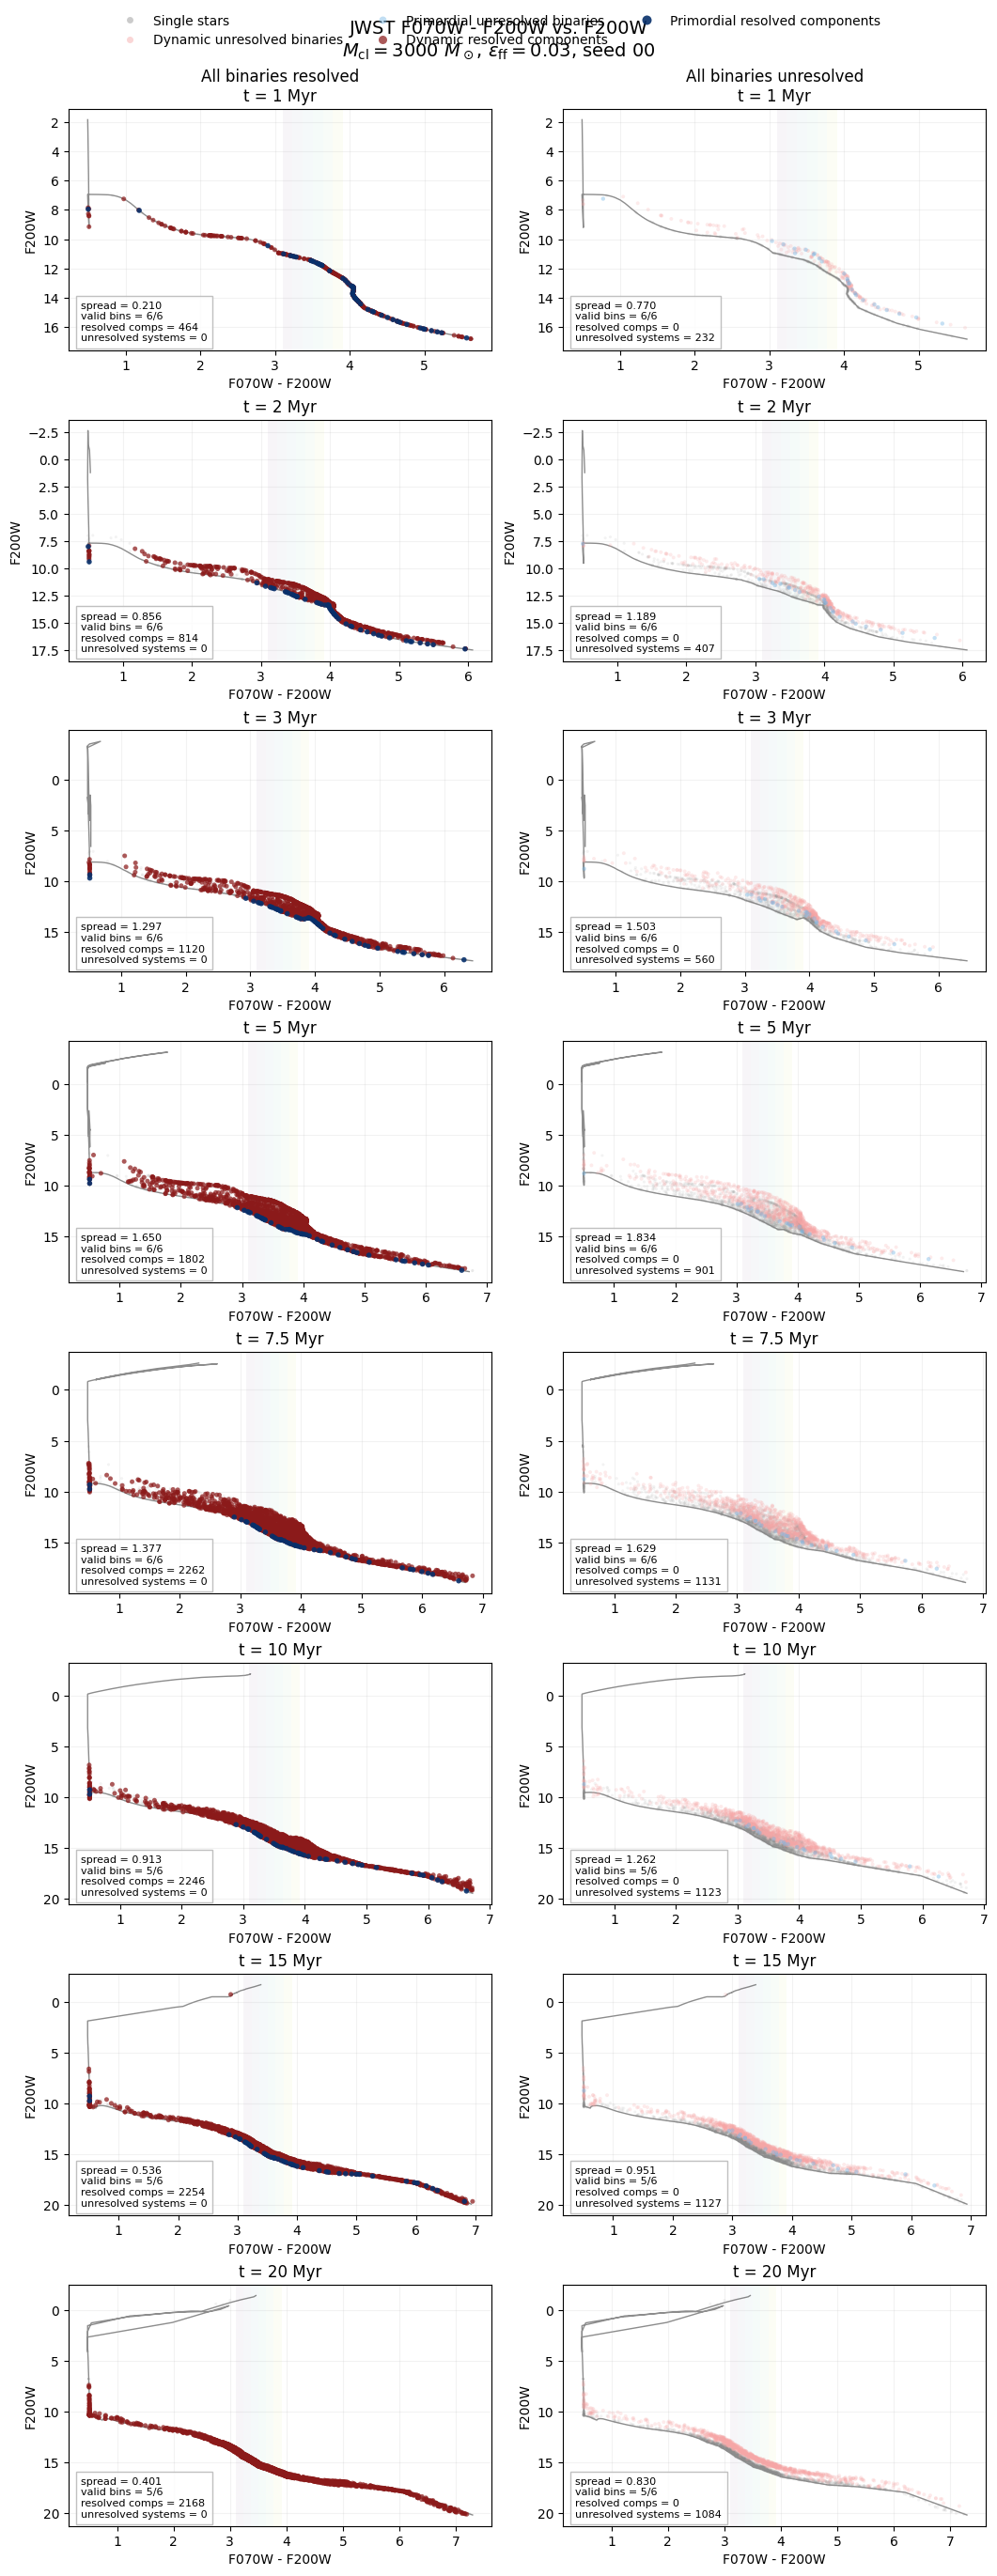

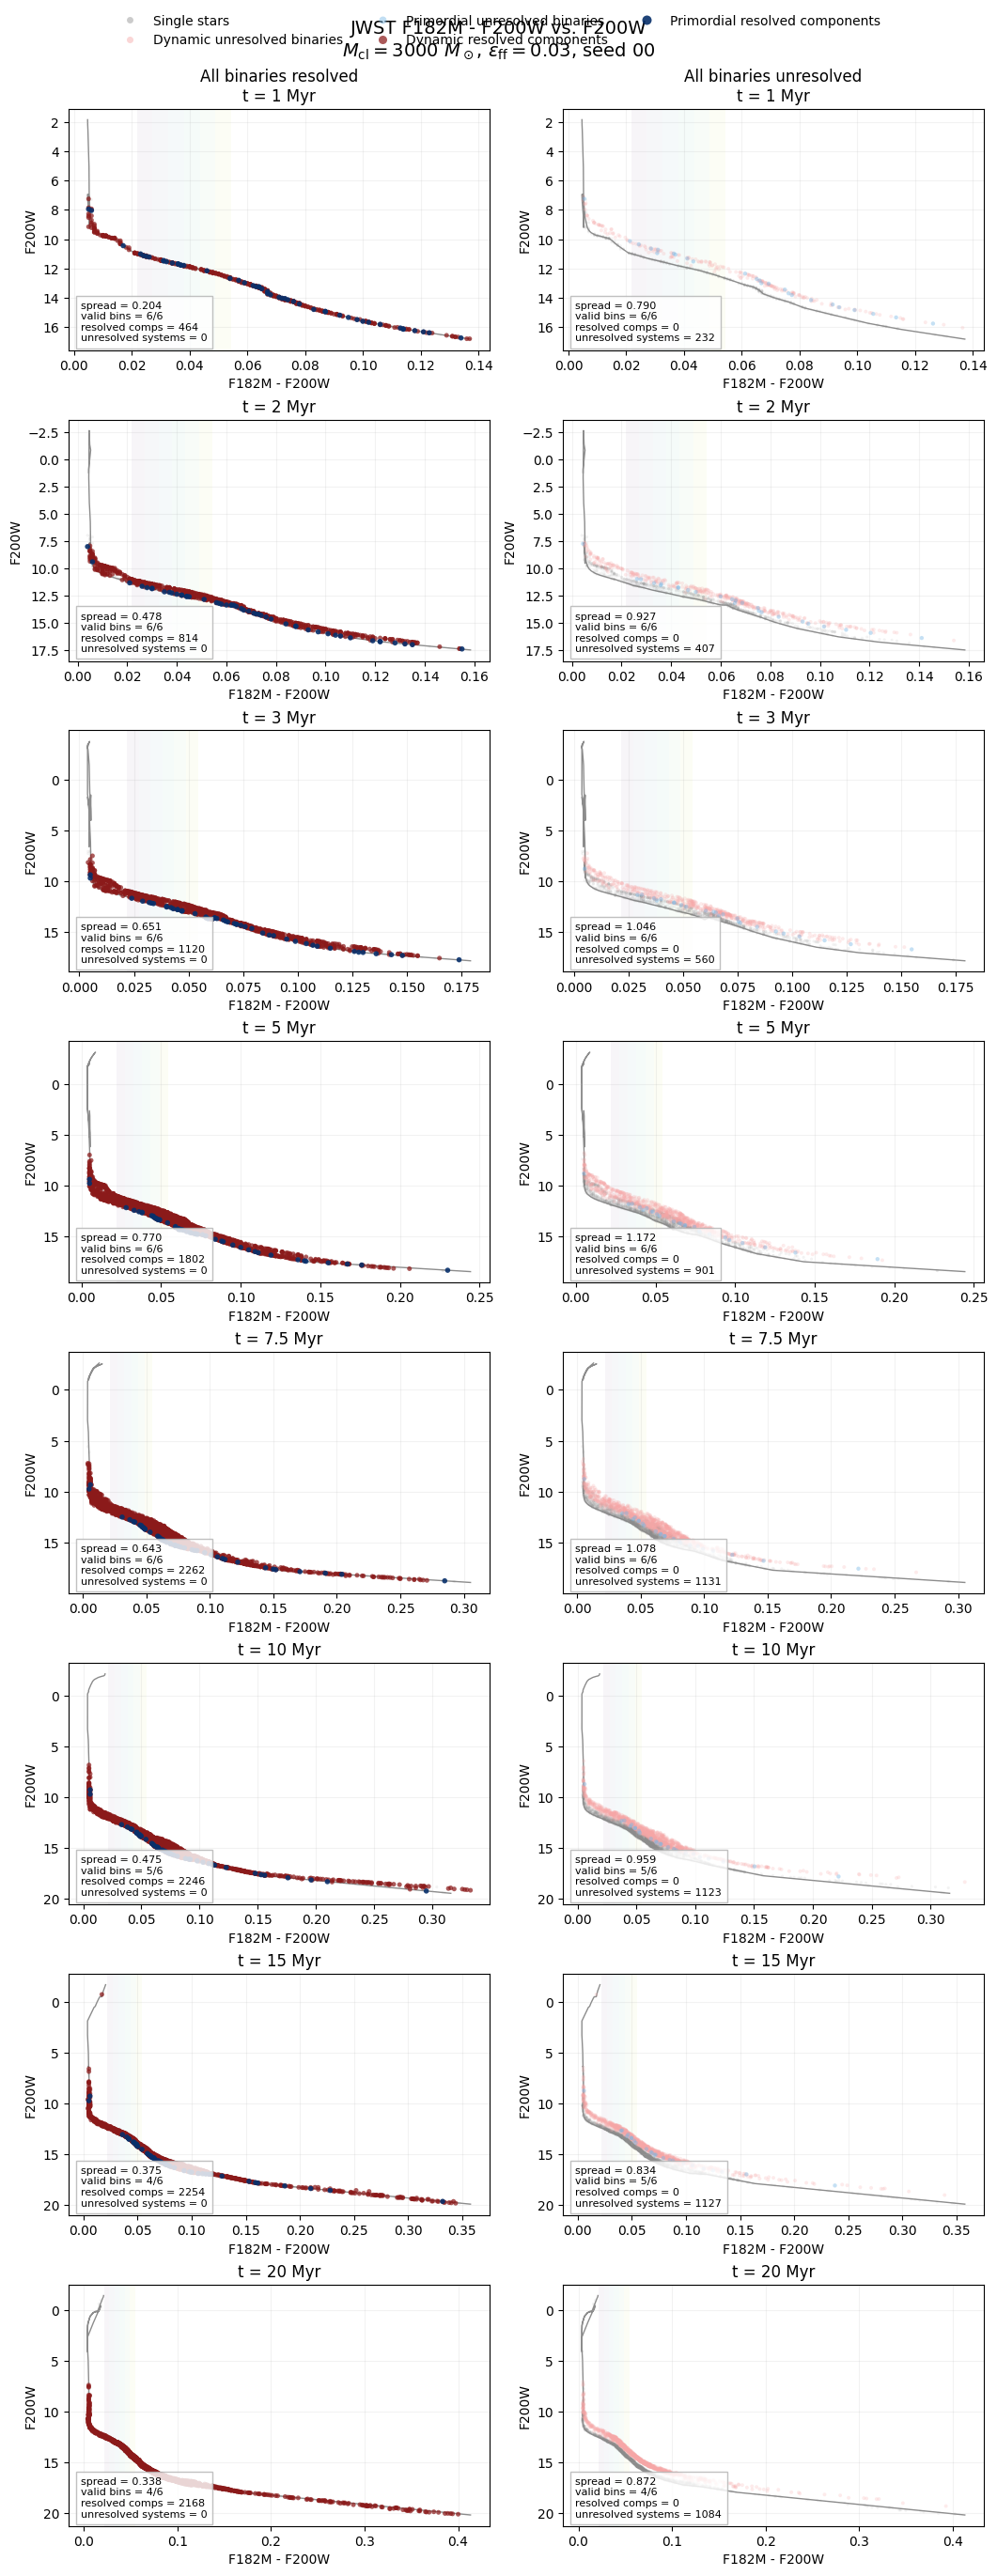

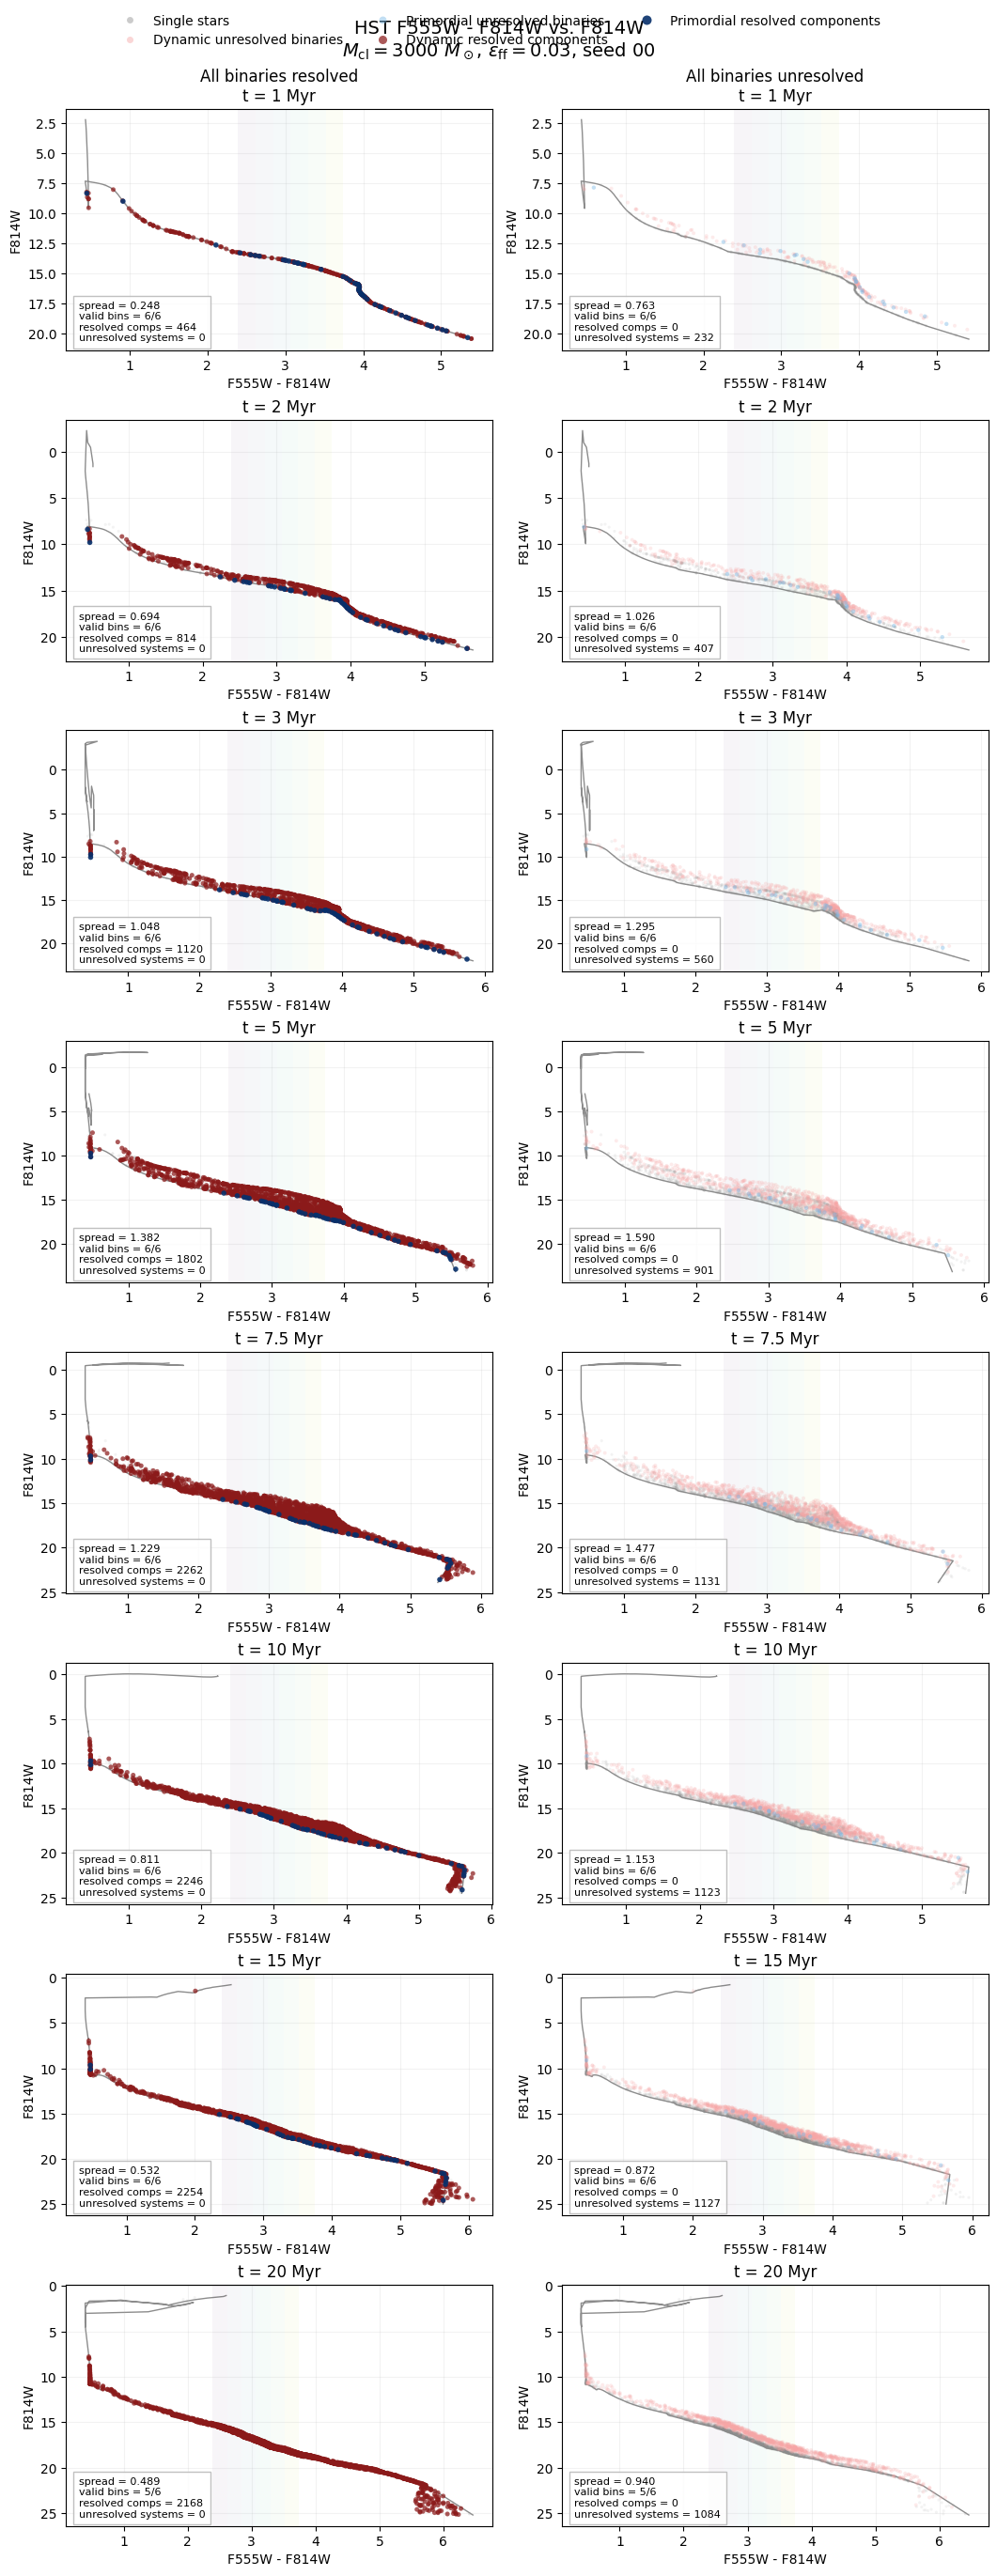

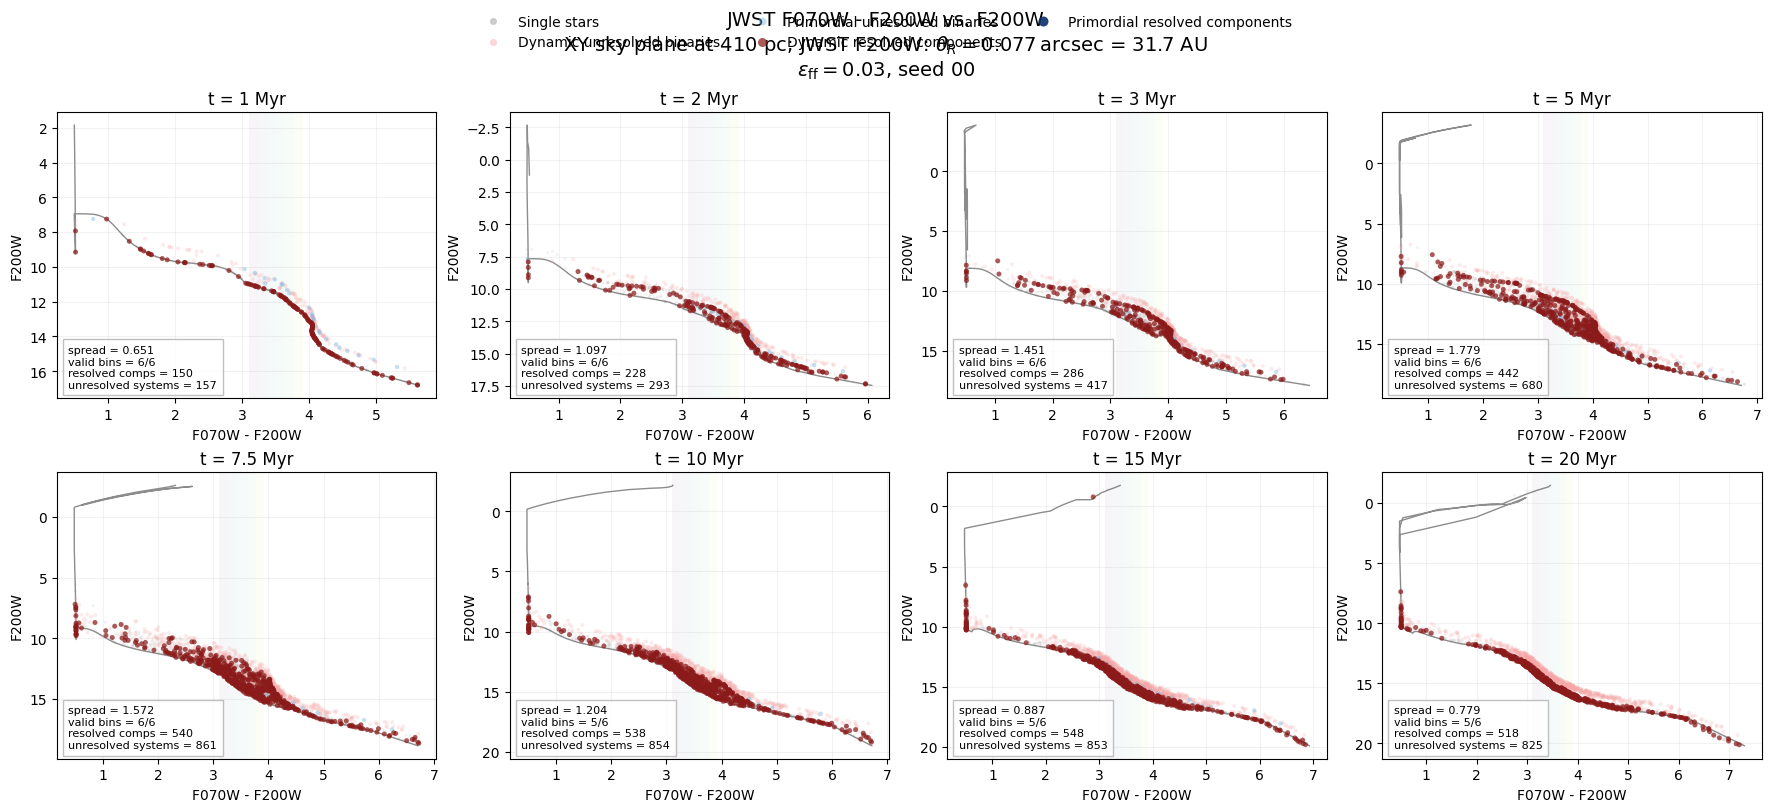

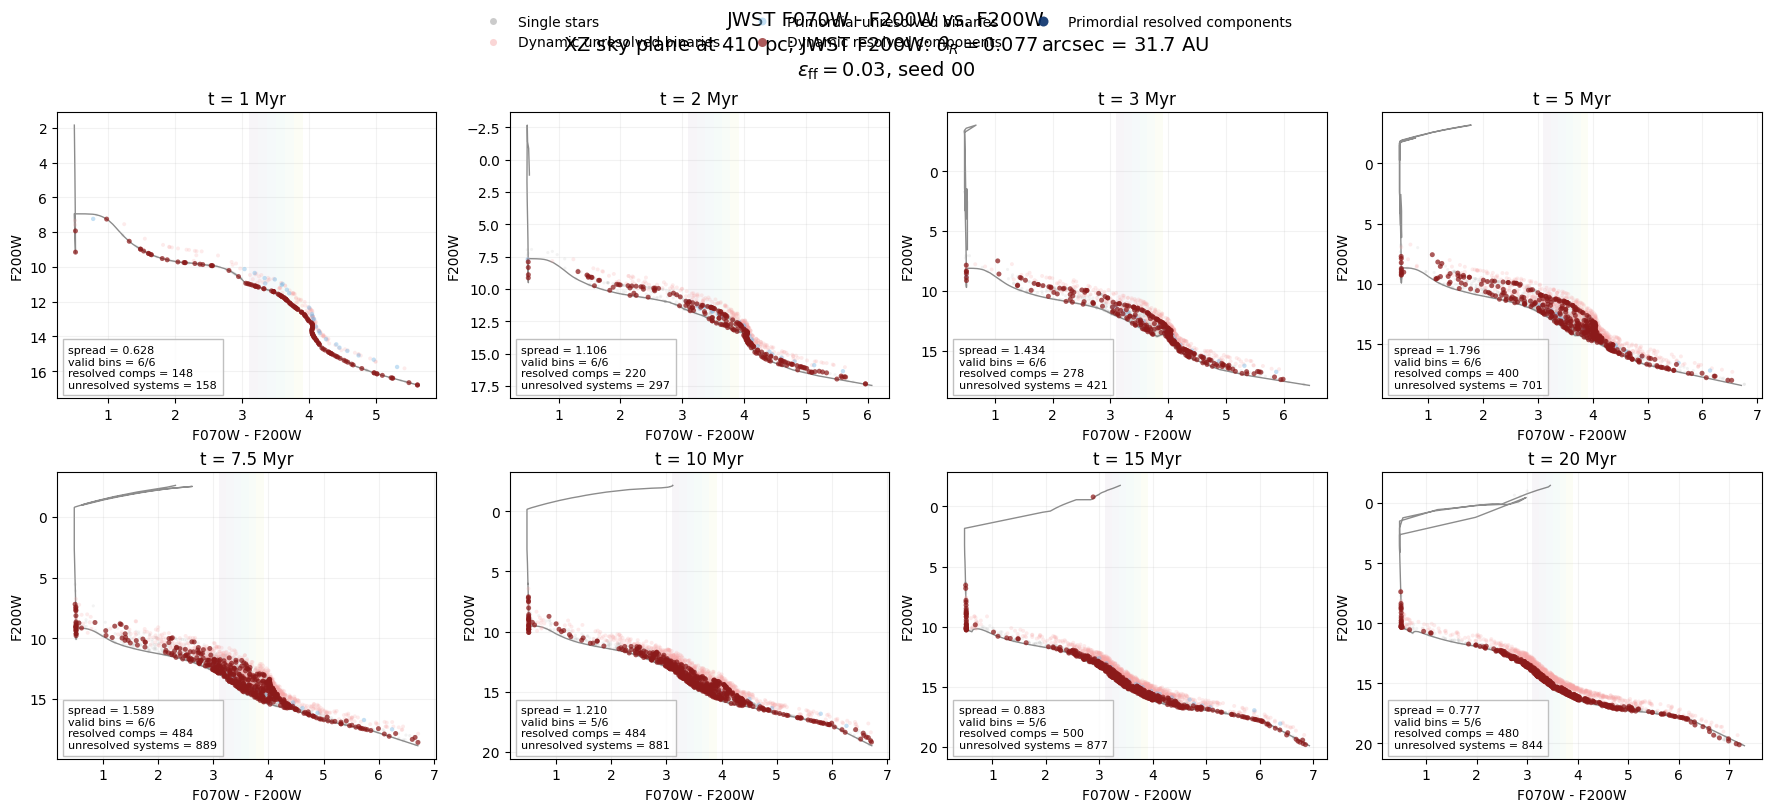

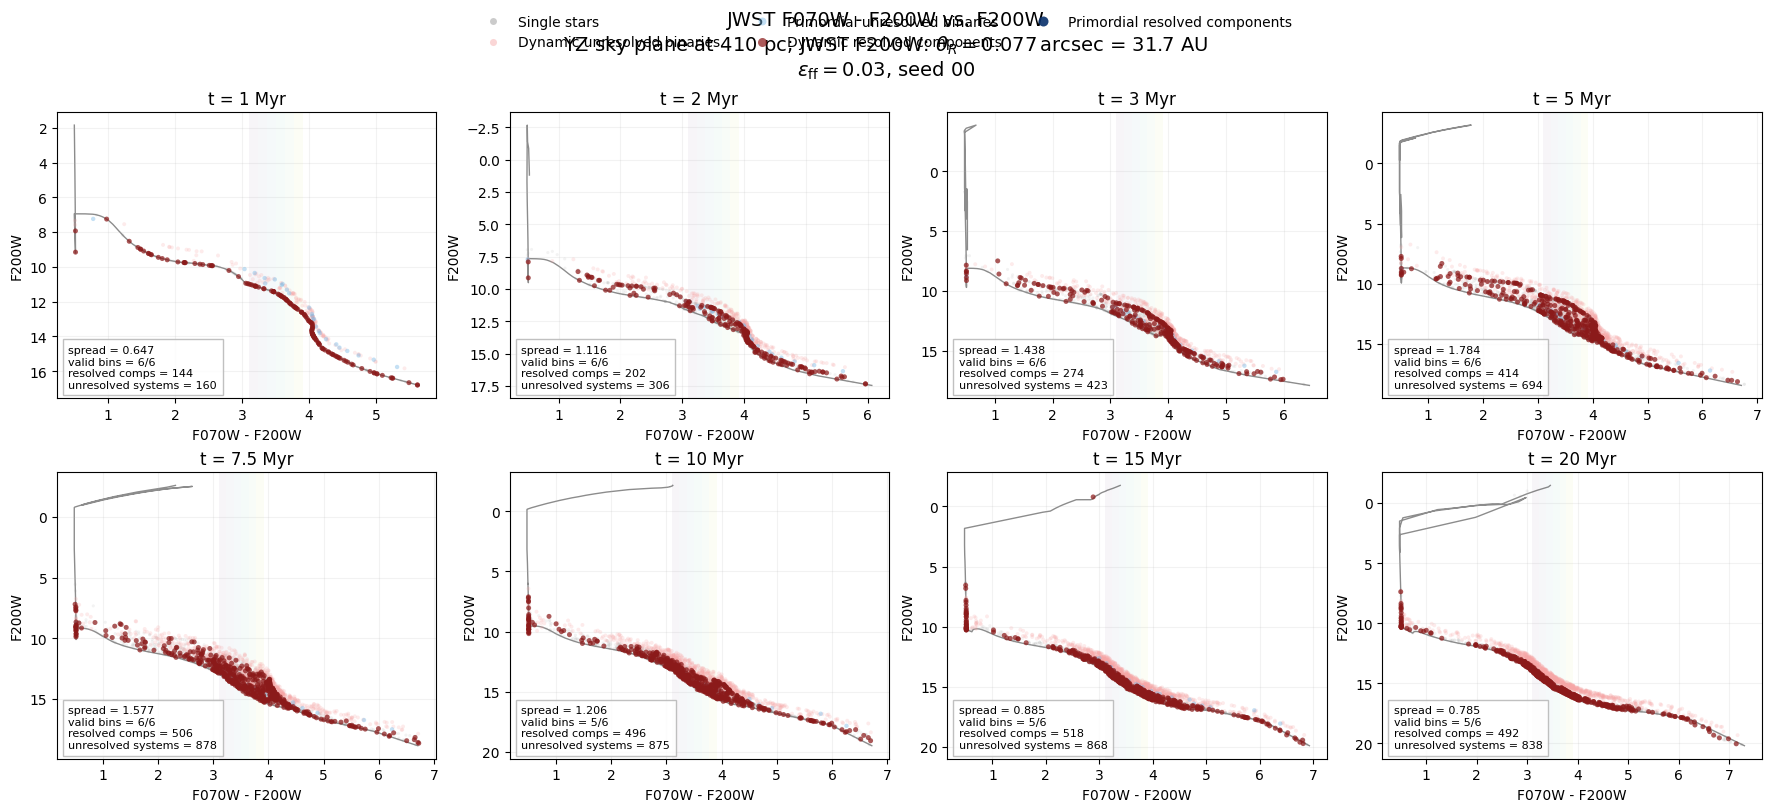

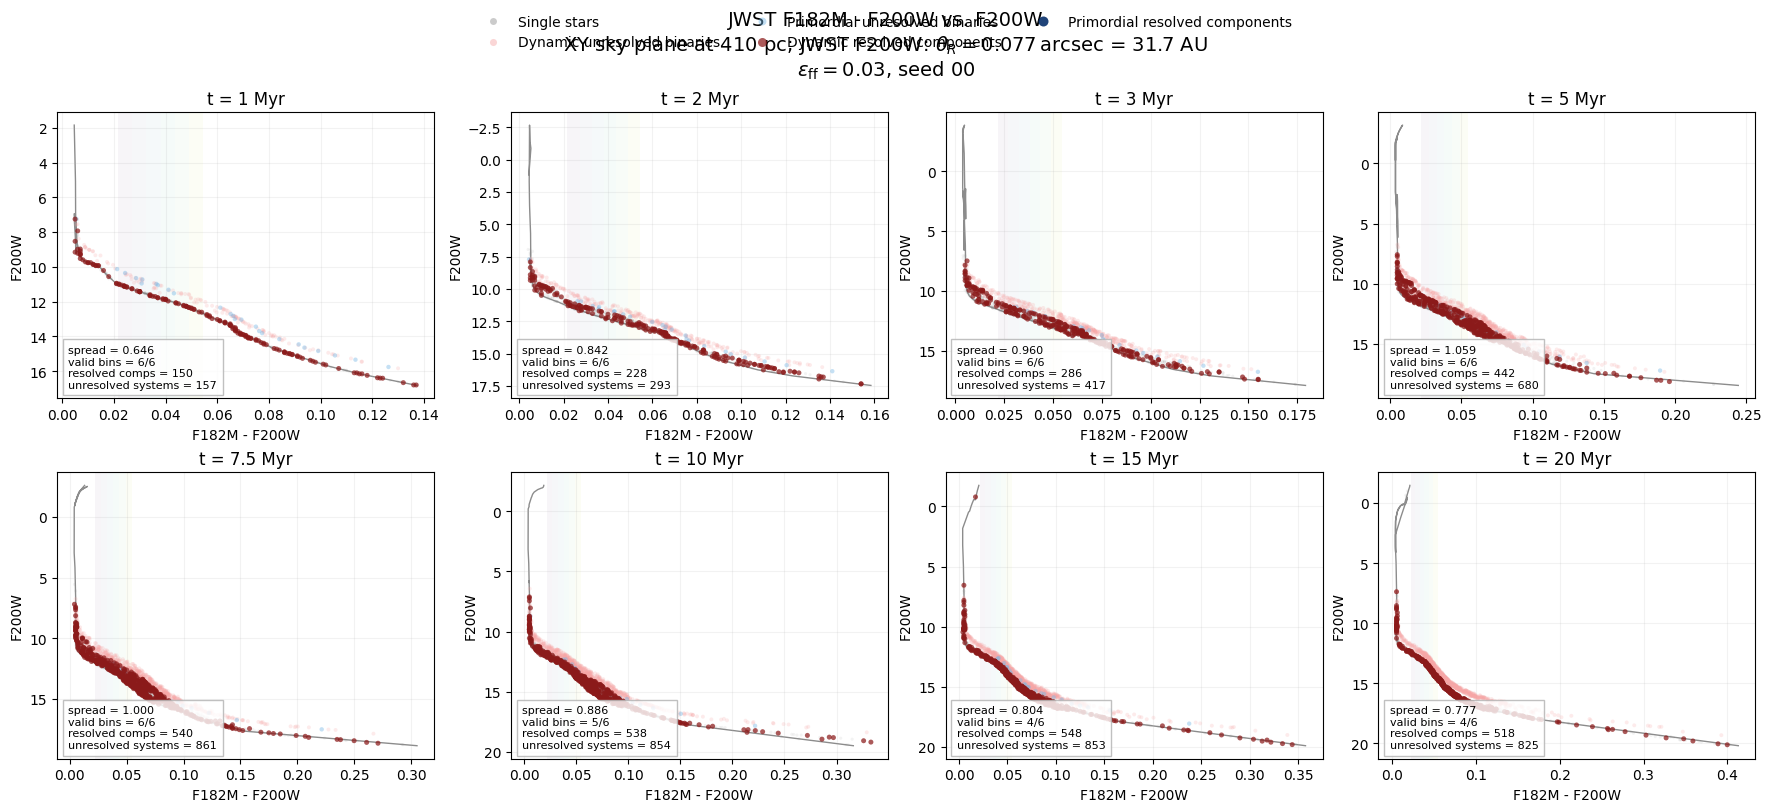

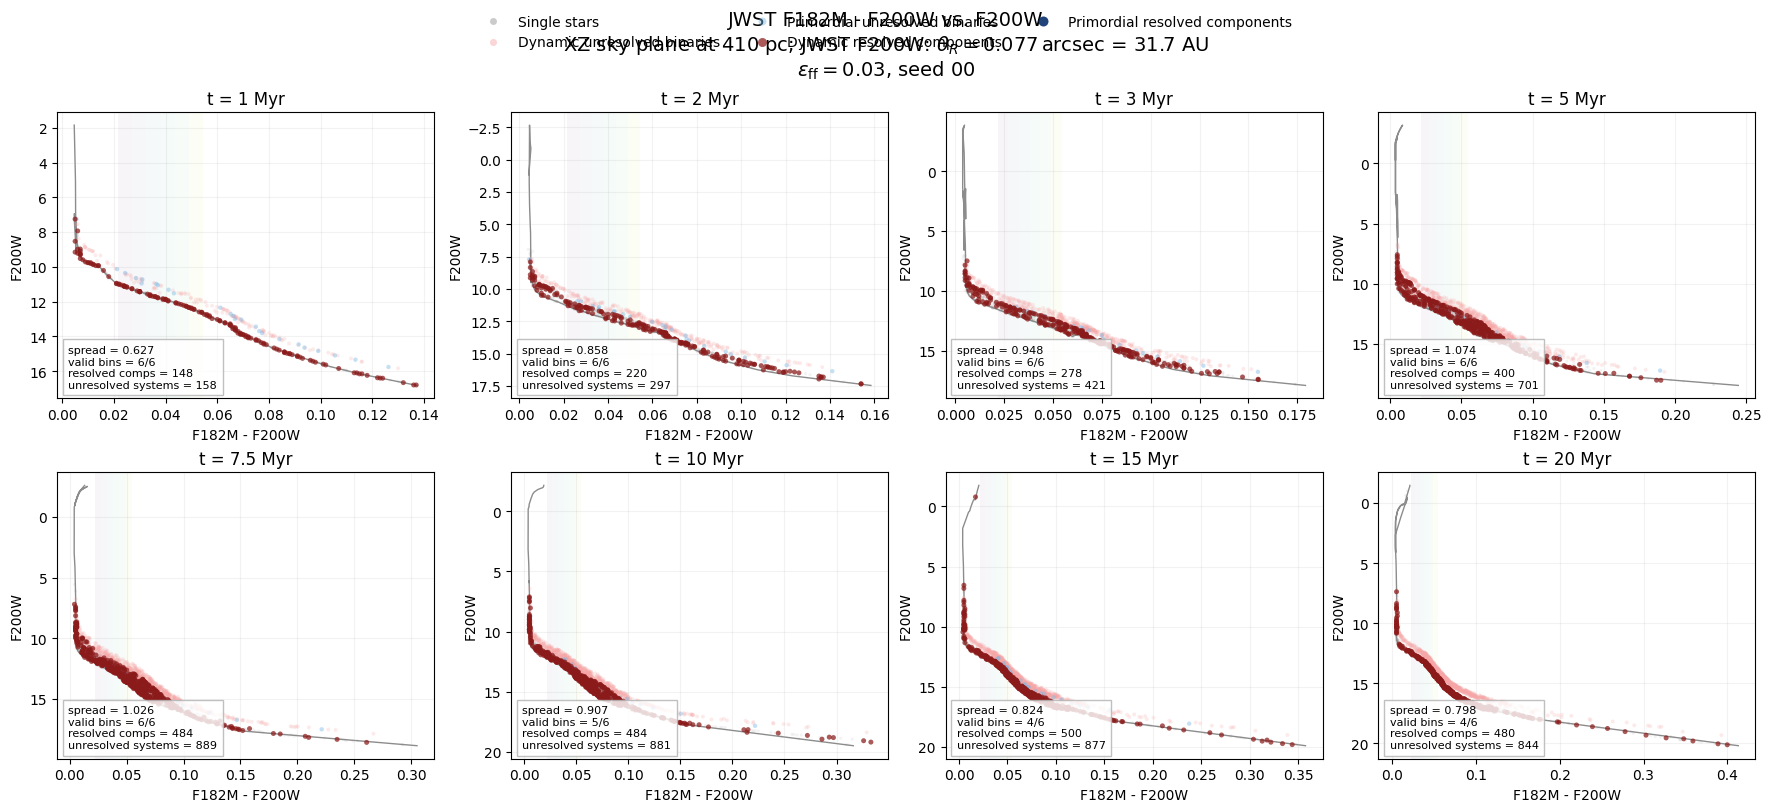

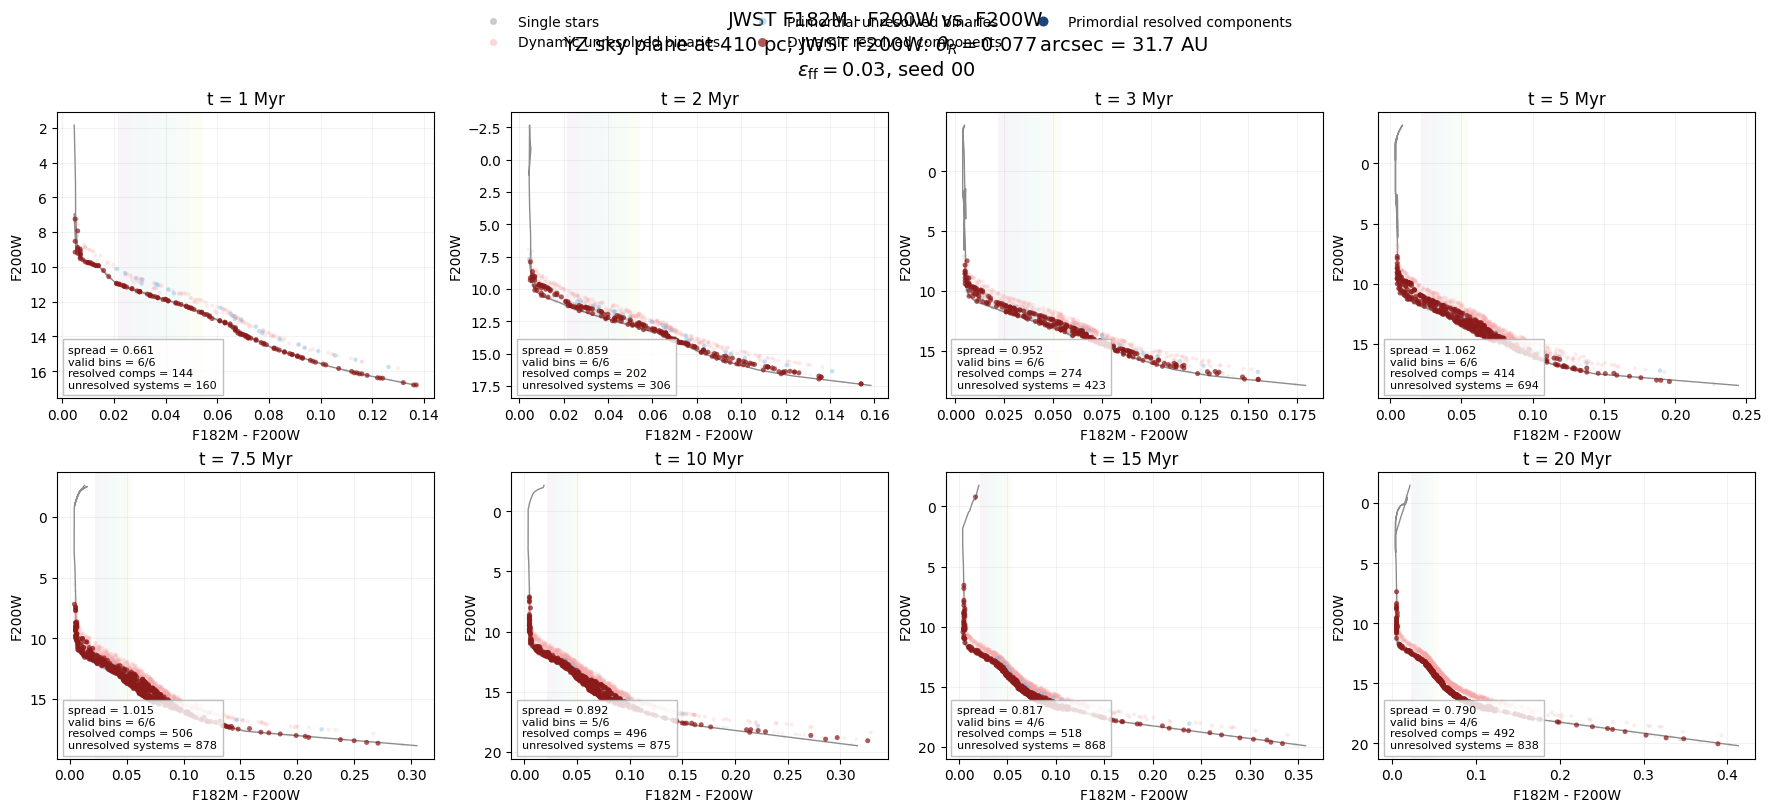

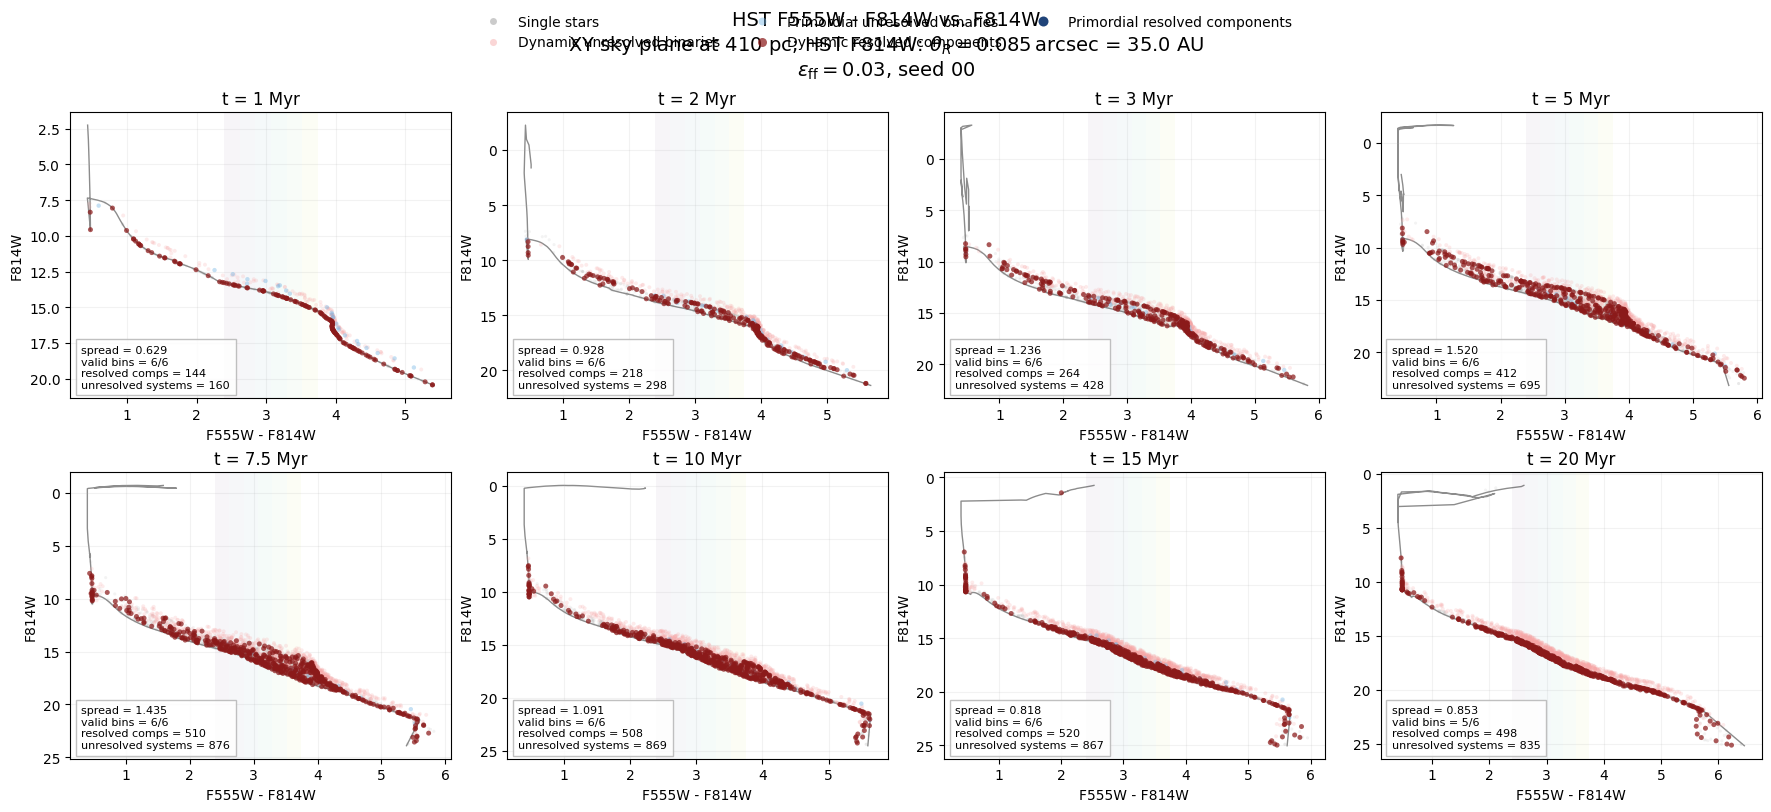

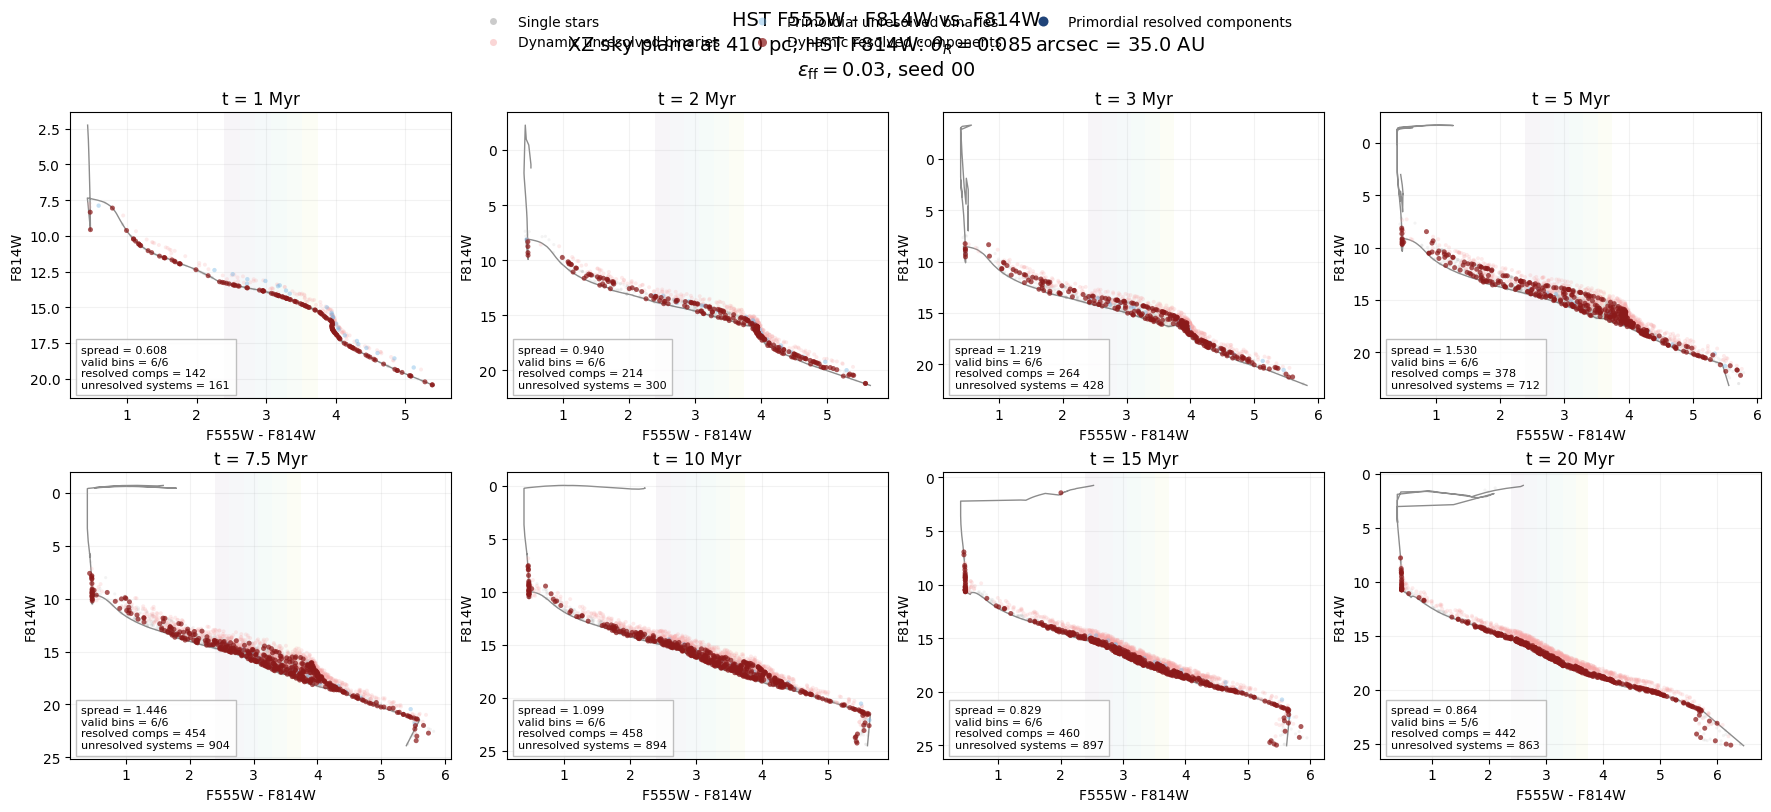

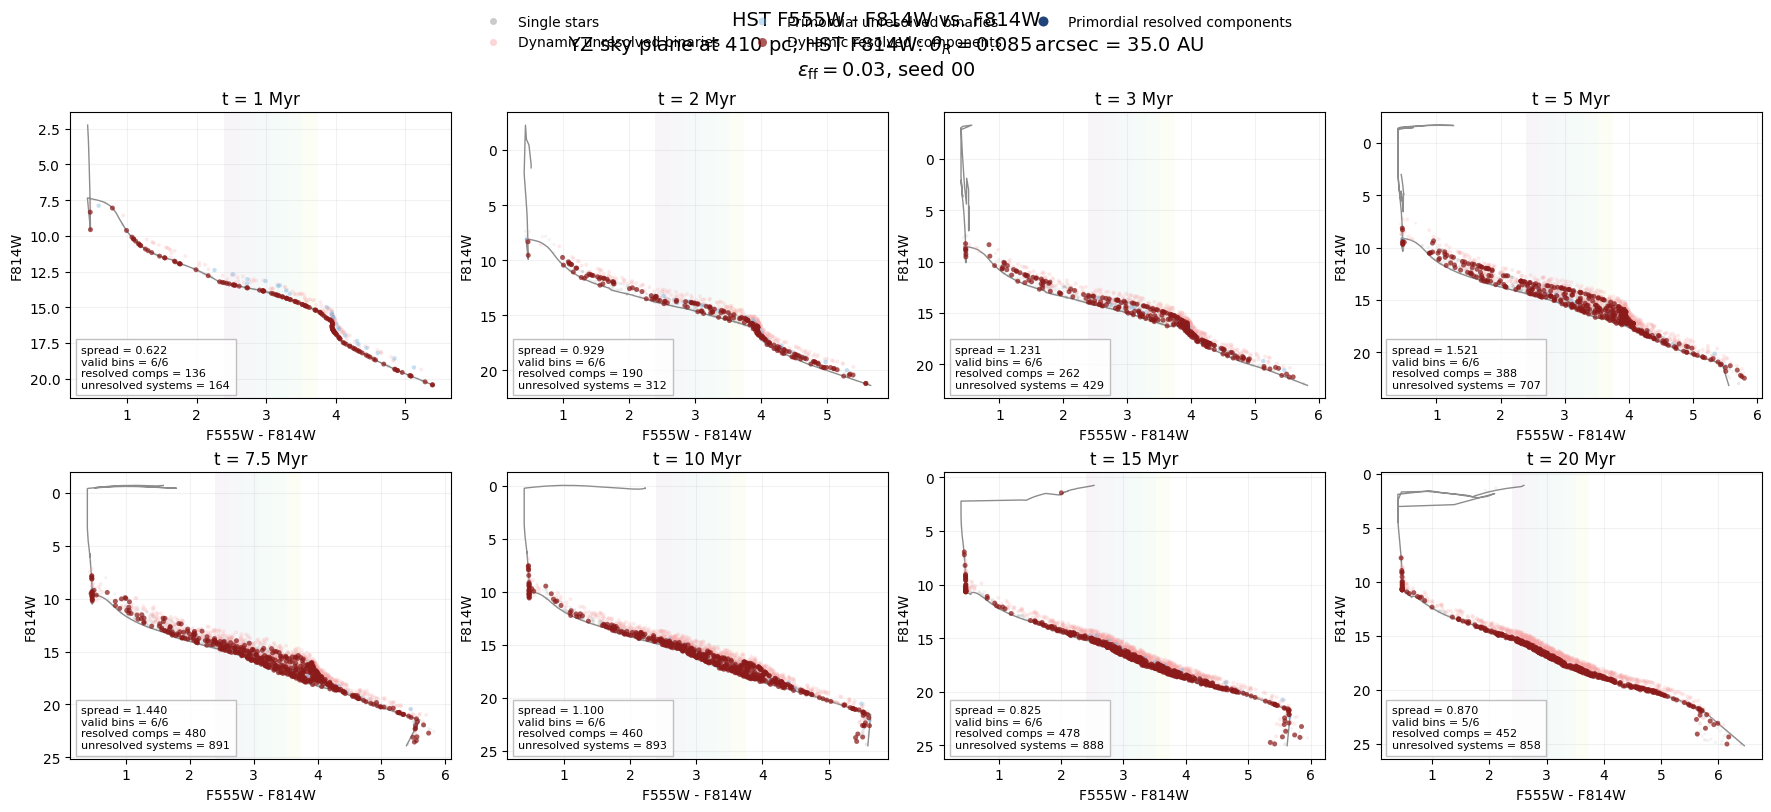

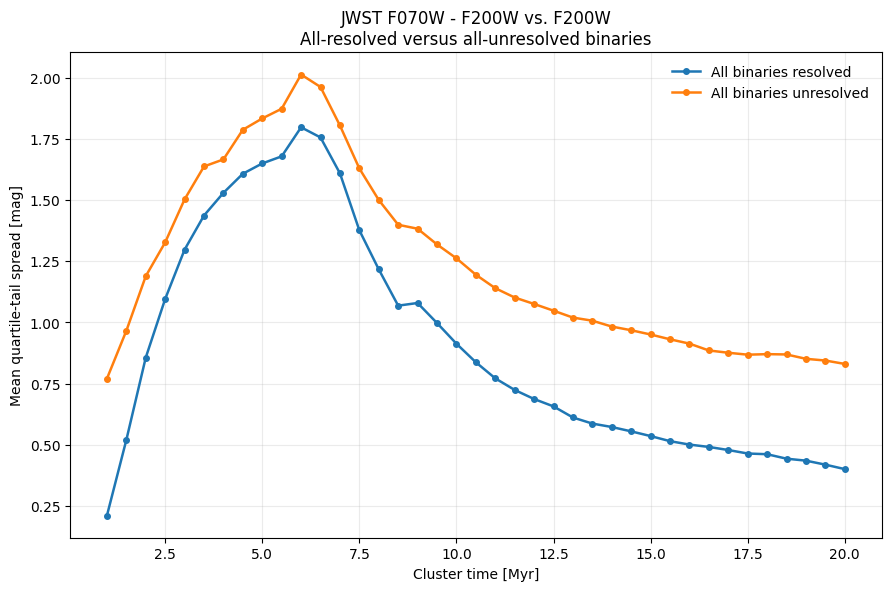

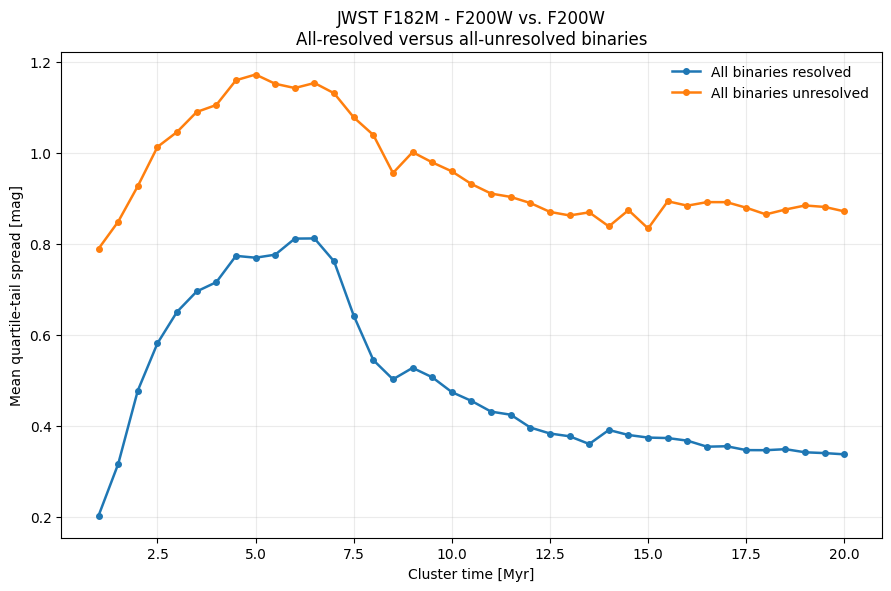

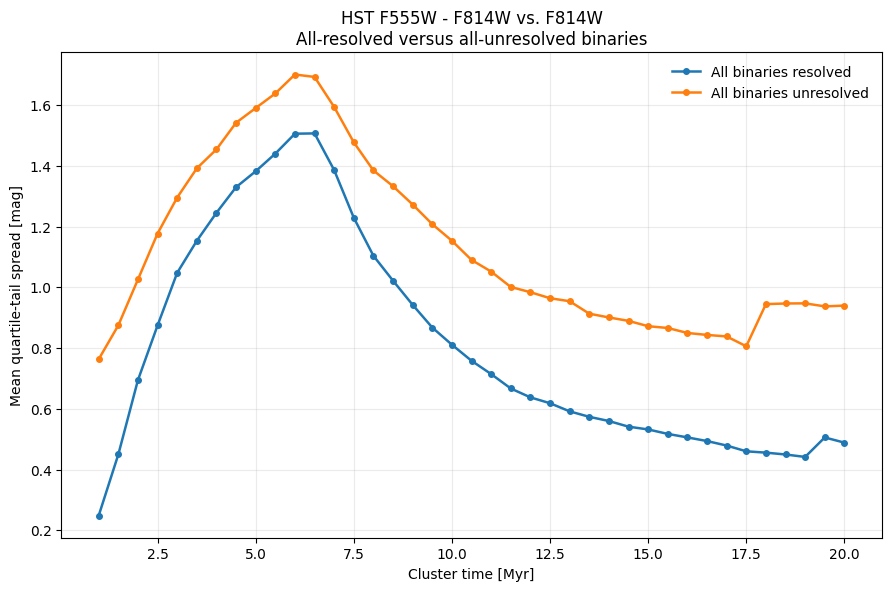

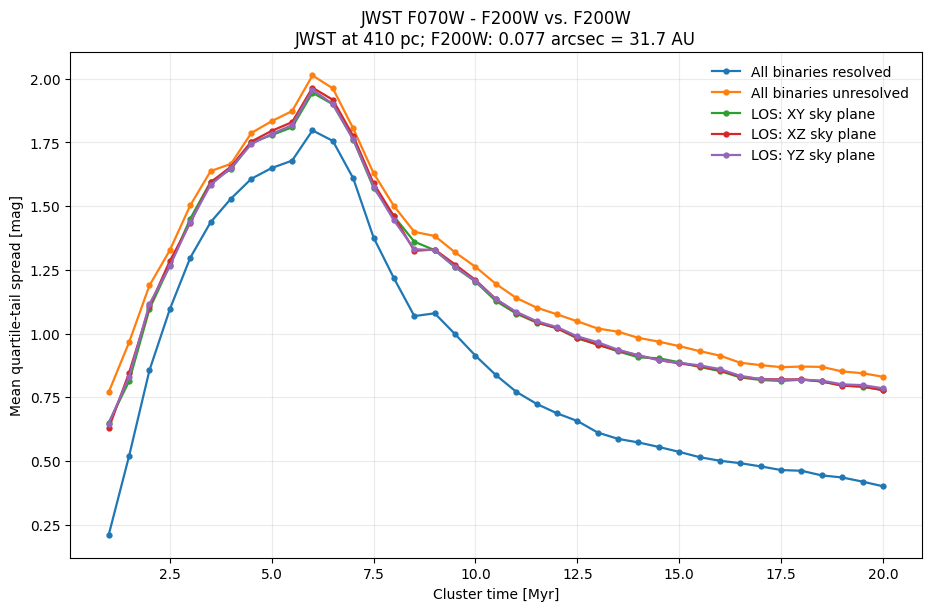

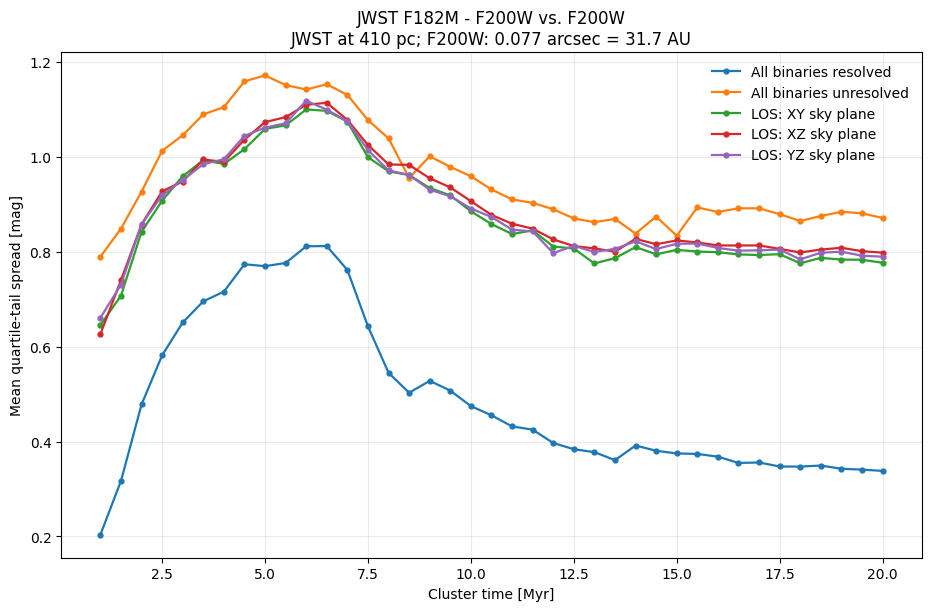

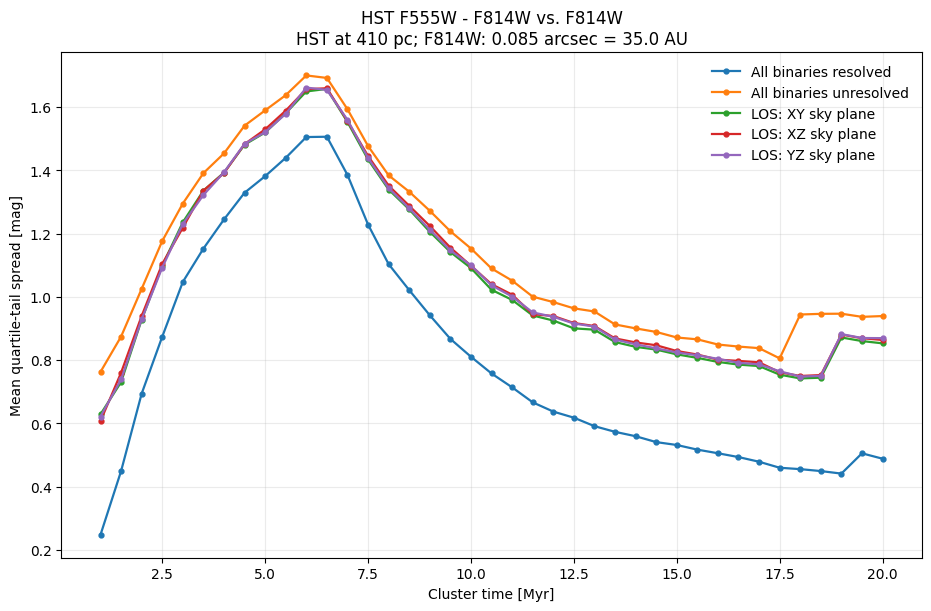

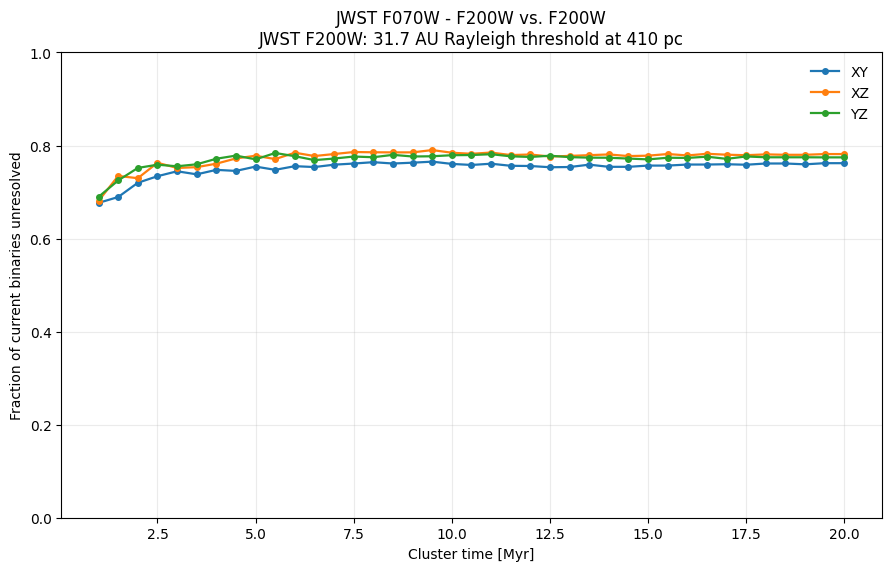

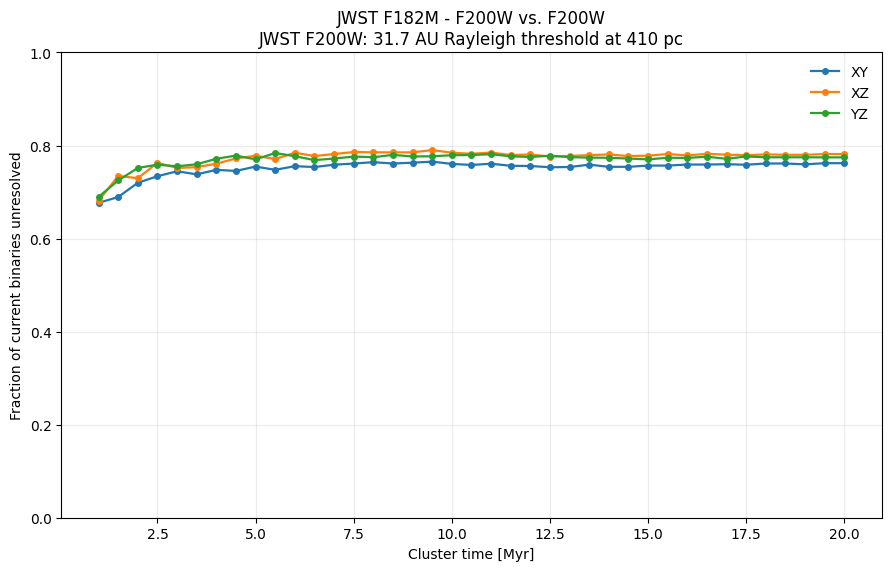

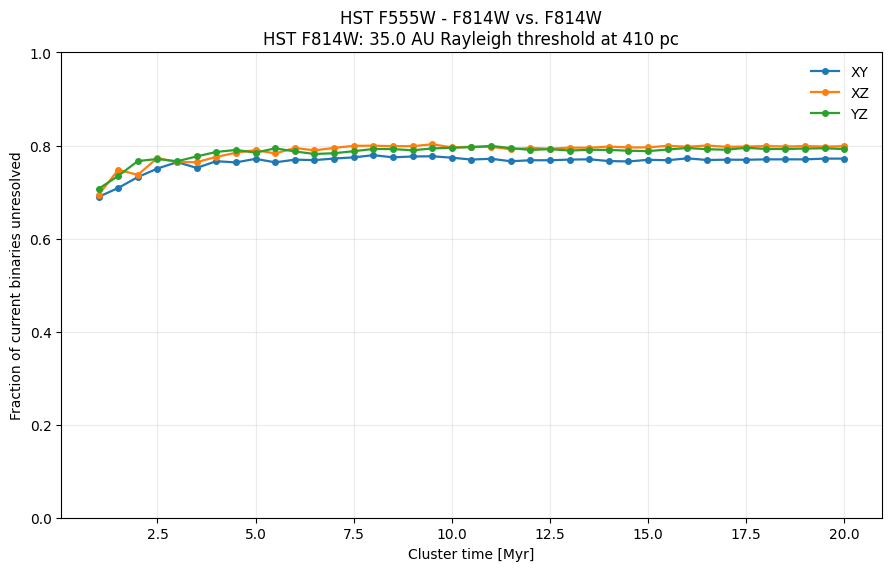

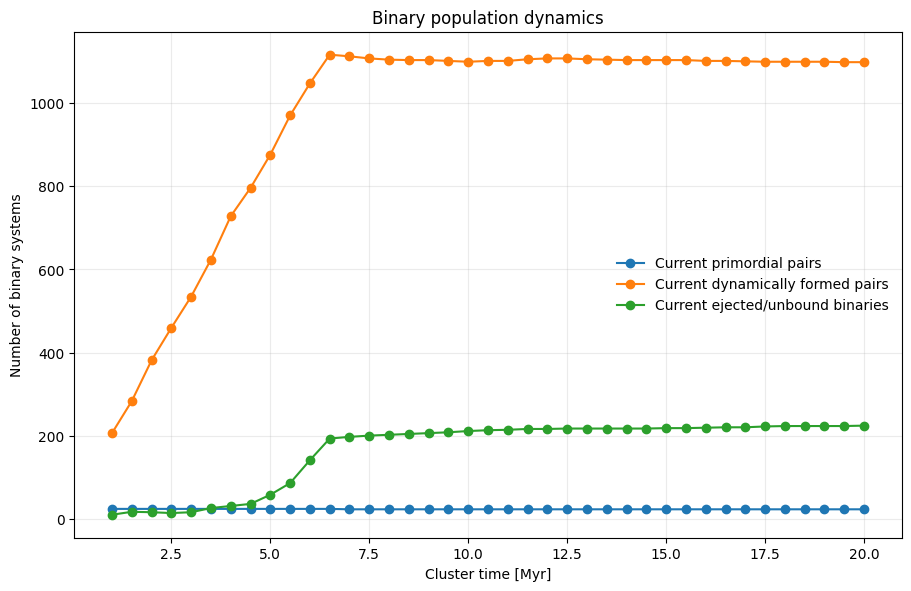

In [15]:
SOURCE_STYLE = {
    'single': dict(
        color='0.55',
        label='Single stars',
        s=5,
        alpha=0.10,
        zorder=1,
    ),
    'dynamic_unresolved_binary': dict(
        color='#f6a6a6',
        label='Dynamic unresolved binaries',
        s=8,
        alpha=0.22,
        zorder=2,
    ),
    'primordial_unresolved_binary': dict(
        color='#76b7e5',
        label='Primordial unresolved binaries',
        s=10,
        alpha=0.42,
        zorder=3,
    ),
    'dynamic_resolved_component': dict(
        color='#8b1a1a',
        label='Dynamic resolved components',
        s=13,
        alpha=0.72,
        zorder=4,
    ),
    'primordial_resolved_component': dict(
        color='#08306b',
        label='Primordial resolved components',
        s=16,
        alpha=0.90,
        zorder=5,
    ),
}

# Plot dominant/light classes first; rarer/darker classes are drawn last.
SOURCE_PLOT_ORDER = (
    'single',
    'dynamic_unresolved_binary',
    'primordial_unresolved_binary',
    'dynamic_resolved_component',
    'primordial_resolved_component',
)


def shade_bins(ax, diagram):
    edges = np.asarray(STATIC_BINS[diagram.key]['edges'], float)
    for i, (low, high) in enumerate(intervals(edges)):
        ax.axvspan(
            low,
            high,
            color=plt.get_cmap('viridis')((i + 0.5) / N_BINS),
            alpha=0.045,
            linewidth=0,
            zorder=0,
        )


def source_legend_handles():
    out = []
    for key in SOURCE_PLOT_ORDER:
        s = SOURCE_STYLE[key]
        out.append(
            Line2D(
                [0], [0],
                marker='o',
                linestyle='none',
                markerfacecolor=s['color'],
                markeredgecolor='none',
                markersize=max(5, np.sqrt(s['s']) * 1.8),
                alpha=max(s['alpha'], 0.45),
                label=s['label'],
            )
        )
    return out


def plot_observed_panel(ax, time_myr, diagram, mode):
    df = observed_catalogs[(float(time_myr), diagram.key, mode)]
    x, y = catalog_xy(df, diagram)

    iso = ISO_GRID.isochrones[nearest_iso_index(time_myr)]
    xi, yi, _ = isochrone_xy(iso, diagram)
    good_iso = np.isfinite(xi) & np.isfinite(yi)

    shade_bins(ax, diagram)
    ax.plot(
        xi[good_iso],
        yi[good_iso],
        color='black',
        alpha=0.45,
        lw=1.0,
        zorder=1,
    )

    classes = df['source_class'].to_numpy(str)
    for source_class in SOURCE_PLOT_ORDER:
        mask = classes == source_class
        good = mask & np.isfinite(x) & np.isfinite(y)
        if not good.any():
            continue

        style = SOURCE_STYLE[source_class]
        ax.scatter(
            x[good],
            y[good],
            s=style['s'],
            alpha=style['alpha'],
            color=style['color'],
            edgecolors='none',
            zorder=style['zorder'],
        )

    if diagram.invert_y:
        ax.invert_yaxis()

    metric = df_metrics[
        np.isclose(df_metrics['snapshot_time_myr'], float(time_myr))
        & (df_metrics['diagram'] == diagram.key)
        & (df_metrics['resolution_mode'] == mode)
    ]

    if len(metric) == 1:
        r = metric.iloc[0]
        spread = (
            f"{r['spread_metric']:.3f}"
            if np.isfinite(r['spread_metric'])
            else 'NaN'
        )
        ax.text(
            0.03,
            0.03,
            f"spread = {spread}\n"
            f"valid bins = {int(r['n_valid_bins'])}/{N_BINS}\n"
            f"resolved comps = {int(r['n_resolved_components'])}\n"
            f"unresolved systems = {int(r['n_unresolved_binary_sources'])}",
            transform=ax.transAxes,
            fontsize=8,
            ha='left',
            va='bottom',
            bbox=dict(facecolor='white', edgecolor='0.7', alpha=0.82),
            zorder=10,
        )

    ax.set_title(f't = {time_myr:g} Myr')
    ax.set_xlabel(diagram.xlabel)
    ax.set_ylabel(diagram.ylabel)
    ax.grid(alpha=0.16)


# Extreme-limit time-evolution diagrams.
for d in DIAGRAMS:
    times = [float(t) for t in DISPLAY_TIMES_MYR if float(t) in base_catalogs]
    fig, axes = plt.subplots(
        len(times),
        2,
        figsize=(10.5, 3.4 * len(times)),
        constrained_layout=True,
        squeeze=False,
    )

    for row, t in enumerate(times):
        plot_observed_panel(axes[row, 0], t, d, ALL_RESOLVED)
        plot_observed_panel(axes[row, 1], t, d, ALL_UNRESOLVED)

    axes[0, 0].set_title('All binaries resolved\n' + axes[0, 0].get_title())
    axes[0, 1].set_title('All binaries unresolved\n' + axes[0, 1].get_title())

    fig.suptitle(
        d.title + '\n'
        + rf'$M_{{\rm cl}}={CLUSTER_MASS_MSUN}\ M_\odot$, '
        + rf'$\epsilon_{{\rm ff}}={EPSILON_FF:g}$, seed {SEED}',
        fontsize=14,
    )
    fig.legend(
        handles=source_legend_handles(),
        loc='upper center',
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.005),
    )
    finish_figure(fig, f'time_evolution_extremes_{d.key}.png')


# LOS time-evolution diagrams for each projection.
for d in DIAGRAMS:
    for projection in PROJECTIONS:
        mode = f'los_{projection.lower()}'
        times = [float(t) for t in DISPLAY_TIMES_MYR if float(t) in base_catalogs]
        ncols = 4
        nrows = int(np.ceil(len(times) / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(4.4 * ncols, 4.0 * nrows),
            constrained_layout=True,
            squeeze=False,
        )

        for ax, t in zip(axes.flat, times):
            plot_observed_panel(ax, t, d, mode)
        for ax in axes.flat[len(times):]:
            ax.set_visible(False)

        r = RESOLUTION_BY_DIAGRAM[d.key]
        fig.suptitle(
            d.title + '\n'
            + f'{projection} sky plane at {OBSERVING_DISTANCE_PC:g} pc; '
            + f'{r["telescope"]} {d.resolution_filter}: '
            + rf'$\theta_R={r["theta_arcsec"]:.3f}\,\mathrm{{arcsec}}$ '
            + f'= {r["physical_resolution_au"]:.1f} AU\n'
            + rf'$\epsilon_{{\rm ff}}={EPSILON_FF:g}$, seed {SEED}',
            fontsize=14,
        )
        fig.legend(
            handles=source_legend_handles(),
            loc='upper center',
            ncol=3,
            frameon=False,
            bbox_to_anchor=(0.5, 1.005),
        )
        finish_figure(
            fig,
            f'time_evolution_los_{projection.lower()}_{d.key}.png',
        )


# Direct all-resolved / all-unresolved spread comparison.
for d in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(8.8, 5.8), constrained_layout=True)
    for mode in (ALL_RESOLVED, ALL_UNRESOLVED):
        sub = df_metrics[
            (df_metrics['diagram'] == d.key)
            & (df_metrics['resolution_mode'] == mode)
        ].sort_values('snapshot_time_myr')
        ax.plot(
            sub['snapshot_time_myr'],
            sub['spread_metric'],
            marker='o',
            ms=4,
            lw=1.8,
            label=MODE_LABELS[mode],
        )

    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel('Mean quartile-tail spread [mag]')
    ax.set_title(d.title + '\nAll-resolved versus all-unresolved binaries')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    finish_figure(fig, f'spread_extreme_binary_resolution_{d.key}.png')


# All five resolution modes on one plot.
for d in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(9.2, 6.0), constrained_layout=True)
    for mode in ALL_MODES:
        sub = df_metrics[
            (df_metrics['diagram'] == d.key)
            & (df_metrics['resolution_mode'] == mode)
        ].sort_values('snapshot_time_myr')
        if sub.empty:
            continue
        ax.plot(
            sub['snapshot_time_myr'],
            sub['spread_metric'],
            marker='o',
            ms=3.5,
            lw=1.6,
            label=MODE_LABELS[mode],
        )

    r = RESOLUTION_BY_DIAGRAM[d.key]
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel('Mean quartile-tail spread [mag]')
    ax.set_title(
        d.title + '\n'
        + f'{r["telescope"]} at {OBSERVING_DISTANCE_PC:g} pc; '
        + f'{d.resolution_filter}: '
        + f'{r["theta_arcsec"]:.3f} arcsec = {r["physical_resolution_au"]:.1f} AU'
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    finish_figure(fig, f'spread_all_binary_resolution_modes_{d.key}.png')


# Fraction unresolved by projection.
for d in DIAGRAMS:
    fig, ax = plt.subplots(figsize=(8.8, 5.6), constrained_layout=True)
    for projection in PROJECTIONS:
        sub = df_binary_fractions[
            (df_binary_fractions['diagram'] == d.key)
            & (df_binary_fractions['projection'] == projection)
        ].sort_values('snapshot_time_myr')
        ax.plot(
            sub['snapshot_time_myr'],
            sub['fraction_unresolved'],
            marker='o',
            ms=4,
            lw=1.6,
            label=projection,
        )

    r = RESOLUTION_BY_DIAGRAM[d.key]
    ax.set_xlabel('Cluster time [Myr]')
    ax.set_ylabel('Fraction of current binaries unresolved')
    ax.set_ylim(0.0, 1.0)
    ax.set_title(
        d.title + '\n'
        + f'{r["telescope"]} {d.resolution_filter}: '
        + f'{r["physical_resolution_au"]:.1f} AU Rayleigh threshold at '
        + f'{OBSERVING_DISTANCE_PC:g} pc'
    )
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
    finish_figure(fig, f'fraction_unresolved_by_projection_{d.key}.png')


# Binary-population census through time.
fig, ax = plt.subplots(figsize=(9.0, 5.8), constrained_layout=True)
ax.plot(
    df_binary_census['snapshot_time_myr'],
    df_binary_census['n_primordial_pairs'],
    marker='o',
    label='Current primordial pairs',
)
ax.plot(
    df_binary_census['snapshot_time_myr'],
    df_binary_census['n_dynamically_formed_pairs'],
    marker='o',
    label='Current dynamically formed pairs',
)
ax.plot(
    df_binary_census['snapshot_time_myr'],
    df_binary_census['n_ejected_binaries'],
    marker='o',
    label='Current ejected/unbound binaries',
)
ax.set_xlabel('Cluster time [Myr]')
ax.set_ylabel('Number of binary systems')
ax.set_title('Binary population dynamics')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
finish_figure(fig, 'binary_population_census_vs_time.png')

## Metadata / manifest

In [16]:
metadata = {
    'analysis_version': 'cmd_resolution',
    'simulation_path': str(SIMULATION_PATH),
    'cluster_mass_msun': CLUSTER_MASS_MSUN,
    'sigma_cloud_g_cm2': SIGMA_CLOUD,
    'epsilon_ff': EPSILON_FF,
    'seed': SEED,
    'photometric_distance_pc': DISTANCE_PC,
    'binary_resolution_distance_pc': OBSERVING_DISTANCE_PC,
    'rayleigh_factor': RAYLEIGH_FACTOR,
    'filter_resolution_config': FILTER_RESOLUTION_CONFIG,
    'projections': PROJECTIONS,
    'hr_diagram_included': False,
    'current_binary_definition': (
        'snapshot.resolve_set(snapshot.unresolved_stars, split_set=True) '
        'evaluated independently at every snapshot'
    ),
    'dynamically_formed_definition': (
        'unordered current component NAME pair was not a binary pair in snapshot 0'
    ),
    'ejected_binary_definition': (
        'current binary appears in snapshot.unbound_stars_unresolved; '
        'resolved component membership used as fallback'
    ),
    'resolution_definition': (
        'Rayleigh theta=1.22 lambda/D using the longest-wavelength filter in '
        'each CMD and that filter telescope aperture; unresolved when projected '
        'separation <= theta * DISTANCE_PC, with DISTANCE_PC=410 pc'
    ),
    'resolution_transition_definition': (
        'state changes are counted only across consecutive 0.5 Myr analysis '
        'snapshots in which the same unordered binary pair is present'
    ),
    'photometric_binary_combination': (
        'Interpolate primary and secondary separately at their own stellar ages '
        'in every band; sum same-band 10^(-0.4m) flux ratios; convert total '
        'flux back to magnitude; calculate CMD color from combined magnitudes.'
    ),
    'temperature_selection_note': (
        'The existing 3000--3600 K selection is retained. For an unresolved '
        'binary, the equivalent composite Teff is used only as the internal '
        'selection proxy; no H-R diagram is generated.'
    ),
    'analysis_times_myr': ANALYSIS_TIMES_MYR.tolist(),
    'display_times_myr': DISPLAY_TIMES_MYR.tolist(),
    'temperature_selection': '3000 <= Teff <= 3600 K',
    'reference_bin_age_myr': REFERENCE_BIN_AGE_MYR,
    'minimum_stars_per_bin': MIN_STARS_PER_BIN,
    'filters': FILTER_OBSMODES,
    'diagrams': [asdict(d) for d in DIAGRAMS],
    'plot_color_scheme': SOURCE_STYLE,
}

(OUTPUT_DIR / 'analysis_metadata.json').write_text(
    json.dumps(metadata, indent=2)
)

manifest = pd.DataFrame([
    ('instrument_resolution_thresholds.csv', 'Rayleigh thresholds using JWST 6.5 m or HST 2.4 m as appropriate.'),
    ('binary_snapshot_census.csv', 'Current primordial/dynamic/ejected binary counts by snapshot.'),
    ('binary_snapshot_history.csv', 'Every current binary system at every analyzed snapshot.'),
    ('binary_lifecycle_summary.csv', 'One-row lifecycle summary for every unique binary pair.'),
    ('dynamically_formed_binaries.csv', 'Unique binary pairs not present as binaries in snapshot 0.'),
    ('ejected_binaries.csv', 'Unique binary pairs classified unbound/ejected at least once.'),
    ('binary_resolution_state_history.csv', 'Resolved/unresolved state for every pair/CMD/projection/snapshot.'),
    ('binary_resolution_transition_summary.csv', 'Per-pair transition counts for every CMD/projection.'),
    ('binaries_changing_resolved_state.csv', 'Pairs with at least one consecutive-snapshot resolution state change.'),
    ('binaries_oscillating_both_directions.csv', 'Pairs with both resolved->unresolved and unresolved->resolved transitions.'),
    ('resolution_transition_statistics.csv', 'Counts of state-changing/oscillating pairs by CMD and projection.'),
    ('binary_resolution_fractions.csv', 'Unresolved fractions and primordial/dynamic resolved-state counts in XY/XZ/YZ.'),
    ('spread_metrics_binary_resolution.csv', 'CMD spread metric for all-resolved, all-unresolved, and three LOS modes.'),
    ('spread_metrics_binary_resolution_per_bin.csv', 'Per-bin CMD spread measurements.'),
    ('time_evolution_extremes_*.png', 'All-resolved versus all-unresolved CMD time-evolution diagrams.'),
    ('time_evolution_los_*_*.png', 'LOS CMDs colored by primordial/dynamic and resolved/unresolved class.'),
    ('spread_extreme_binary_resolution_*.png', 'Extreme-case CMD spread comparison.'),
    ('spread_all_binary_resolution_modes_*.png', 'Extreme plus XY/XZ/YZ CMD spread curves.'),
    ('fraction_unresolved_by_projection_*.png', 'Unresolved fraction versus time.'),
    ('binary_population_census_vs_time.png', 'Primordial/dynamic/ejected binary counts versus time.'),
    ('analysis_metadata.json', 'Full configuration and operational definitions.'),
], columns=['filename', 'description'])

manifest.to_csv(OUTPUT_DIR / 'output_manifest.csv', index=False)

print('\n' + '=' * 80)
print('Binary-resolution CMD analysis complete')
print('Outputs:', OUTPUT_DIR.resolve())
print('Cache:', CACHE_DIR.resolve())
print('Resolution table:', (OUTPUT_DIR / 'instrument_resolution_thresholds.csv').resolve())
print('Spread table:', (OUTPUT_DIR / 'spread_metrics_binary_resolution.csv').resolve())
print('Lifecycle table:', (OUTPUT_DIR / 'binary_lifecycle_summary.csv').resolve())
print('Resolution transitions:', (OUTPUT_DIR / 'binary_resolution_transition_summary.csv').resolve())


Binary-resolution CMD analysis complete
Outputs: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-18-unresolved-experiment/binary_resolution_seed00_cmd_outputs
Cache: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-18-unresolved-experiment/binary_resolution_seed00_cmd_cache
Resolution table: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-18-unresolved-experiment/binary_resolution_seed00_cmd_outputs/instrument_resolution_thresholds.csv
Spread table: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-18-unresolved-experiment/binary_resolution_seed00_cmd_outputs/spread_metrics_binary_resolution.csv
Lifecycle table: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-18-unresolved-experiment/binary_resolution_seed00_cmd_outputs/binary_lifecycle_summary.csv
Resolution transitions: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/09-18-unresolved-experiment/binary_resolution_seed00_cmd_outputs/b